# 7. Feature Engineering

Feature engineering is the process of creating new variables from existing information that better represent customer behavior and improve predictive performance.

Raw financial datasets often contain information that can be transformed into more meaningful indicators of credit risk. Carefully engineered features allow machine learning algorithms to capture hidden relationships that may not be apparent from the original variables.

In this notebook, we engineer demographic, employment, financial, housing, and external source features while ensuring data quality and business interpretability.

**Objectives**

- Load the cleaned dataset from Notebook 03
- Create meaningful business-driven features
- Encode categorical variables
- Validate engineered features
- Save the final dataset for model development

In [3]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## 7.2 Load Cleaned Dataset

The cleaned dataset generated in Notebook 03 is loaded for feature engineering.

At this stage, missing value treatment, duplicate removal, datatype corrections, and data quality improvements have already been completed.

In [4]:
# ============================================
# Load Cleaned Dataset
# ============================================

df = pd.read_csv("../data/processed/application_train_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (307511, 128)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS,PHONE_CHANGE_YEARS,EMPLOYMENT_YEARS,HAS_EMPLOYMENT_INFO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.9,9.987680,5.804244,3.104723,1.74,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.9,3.247091,0.796715,2.266940,3.25,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,26.0,1,1,1,1,1,0,Labo

## 7.3 Dataset Verification

Before creating new features, it is important to verify that the cleaned dataset has been loaded correctly.

This includes checking the dataset dimensions, data types, and confirming that missing value treatment from Notebook 03 has been successfully applied.

In [5]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 128 entries, SK_ID_CURR to HAS_EMPLOYMENT_INFO
dtypes: float64(71), int64(41), str(16)
memory usage: 300.3 MB


In [6]:
# First Five Rows

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS,PHONE_CHANGE_YEARS,EMPLOYMENT_YEARS,HAS_EMPLOYMENT_INFO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.9,9.987680,5.804244,3.104723,1.74,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.9,3.247091,0.796715,2.266940,3.25,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,26.0,1,1,1,1,1,0,Labo

In [7]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.0,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.000000,513531.000000,808650.000000,4.050000e+06
...,...,...,...,...,...,...,...,...
REGISTRATION_YEARS,307511.0,13.651253,9.645137,0.0,5.503080,12.331280,20.477754,6.754826e+01
ID_PUBLISH_YEARS,307511.0,8.197679,4.132650,0.0,4.709104,8.908966,11.770020,1.970431e+01
PHONE_CHANGE_YEARS,307511.0,2.636162,2.263675,0.0,0.750171,2.072553,4.298426,1.175085e+01
EMPLOYMENT_YEARS,252137.0,6.527498,6.402080,0.0,2.100000,4.510000,8.690000,4.904000e+01


## 7.4 Existing Features

Understanding the available variables helps identify opportunities for creating meaningful derived features.

These engineered variables will improve the model's ability to distinguish between low-risk and high-risk loan applicants.

In [8]:
print("Total Features:", len(df.columns))

Total Features: 128


In [9]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [113]:
# Income per Employment Year

df["INCOME_PER_EMPLOYMENT_YEAR"] = np.where(
    df["EMPLOYMENT_YEARS"] > 0,
    df["AMT_INCOME_TOTAL"] / df["EMPLOYMENT_YEARS"],
    0
)

In [114]:
df["INCOME_PER_EMPLOYMENT_YEAR"].describe()

count    3.075110e+05
mean     6.430929e+04
std      2.205948e+05
min      0.000000e+00
25%      8.653846e+03
50%      2.617970e+04
75%      6.445312e+04
max      4.642857e+07
Name: INCOME_PER_EMPLOYMENT_YEAR, dtype: float64

In [115]:
df["INCOME_PER_EMPLOYMENT_YEAR"].isnull().sum()

np.int64(0)

## 7.5 Feature Engineering Strategy

Feature engineering transforms existing variables into more informative predictors that better capture the financial behavior and repayment capacity of loan applicants.

Rather than relying solely on raw variables, engineered features incorporate business knowledge to create indicators that are more relevant for credit risk assessment.

The engineered features in this notebook are grouped into the following categories:

- Demographic Features
- Employment Features
- Financial Ratio Features
- Housing & Asset Features
- External Source Features
- Categorical Encoding

These engineered variables are expected to improve model performance while increasing interpretability for business stakeholders.

## 7.6 Financial Ratio Features

Financial variables such as income, credit amount, and loan annuity are among the most important predictors of credit risk. However, these variables are often more informative when expressed as ratios rather than absolute values.

Ratio-based features capture an applicant's repayment capacity, debt burden, and financial affordability more effectively than individual variables. These engineered features are widely used in credit scoring models because they reflect meaningful business relationships between income and borrowing behaviour.

In this section, we create several financial ratio features that are expected to improve the predictive performance of our credit risk model.

### 7.6.1 Credit-to-Income Ratio

The Credit-to-Income Ratio measures the size of the requested loan relative to the applicant's annual income.

A higher ratio indicates that the applicant is requesting a larger loan compared to their earning capacity. Applicants with extremely high ratios may experience greater financial stress, making this feature an important indicator of credit risk.

In [10]:
# ============================================
# Credit-to-Income Ratio
# ============================================

df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

print("Feature Created Successfully!")

df["CREDIT_INCOME_RATIO"].describe()

Feature Created Successfully!


count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64

In [11]:
#Validation
df["CREDIT_INCOME_RATIO"].head()

0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: CREDIT_INCOME_RATIO, dtype: float64

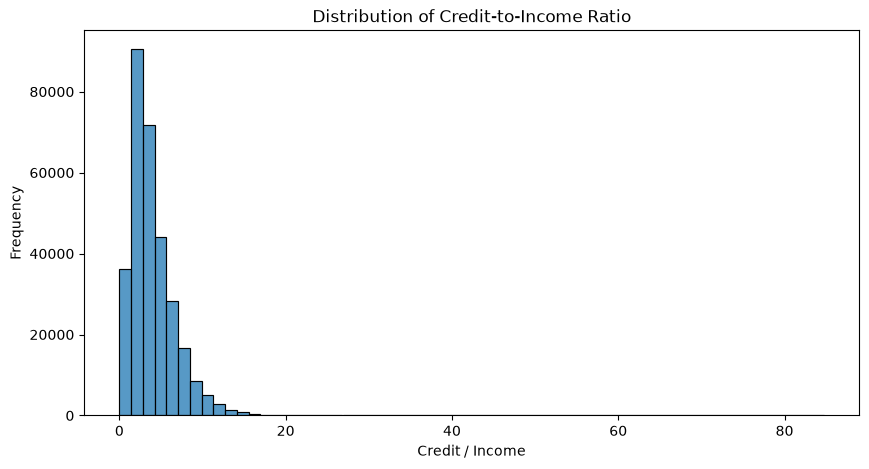

In [12]:
#Distribution of Credit-to-Income Ratio
plt.figure(figsize=(10,5))

sns.histplot(
    df["CREDIT_INCOME_RATIO"],
    bins=60
)

plt.title("Distribution of Credit-to-Income Ratio")
plt.xlabel("Credit / Income")
plt.ylabel("Frequency")

plt.show()

In [13]:
#Default rate Analysis
credit_income_default = (
    df.groupby(
        pd.qcut(
            df["CREDIT_INCOME_RATIO"],
            10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

credit_income_default

,CREDIT_INCOME_RATIO,TARGET
0,"(0.00381, 1.332]",0.069085
1,"(1.332, 1.818]",0.077615
2,"(1.818, 2.266]",0.081126
3,"(2.266, 2.764]",0.090212
4,"(2.764, 3.265]",0.086542
5,"(3.265, 3.906]",0.091962
6,"(3.906, 4.725]",0.086168
7,"(4.725, 5.769]",0.079510
8,"(5.769, 7.488]",0.074412
9,"(7.488, 84.737]",0.070656


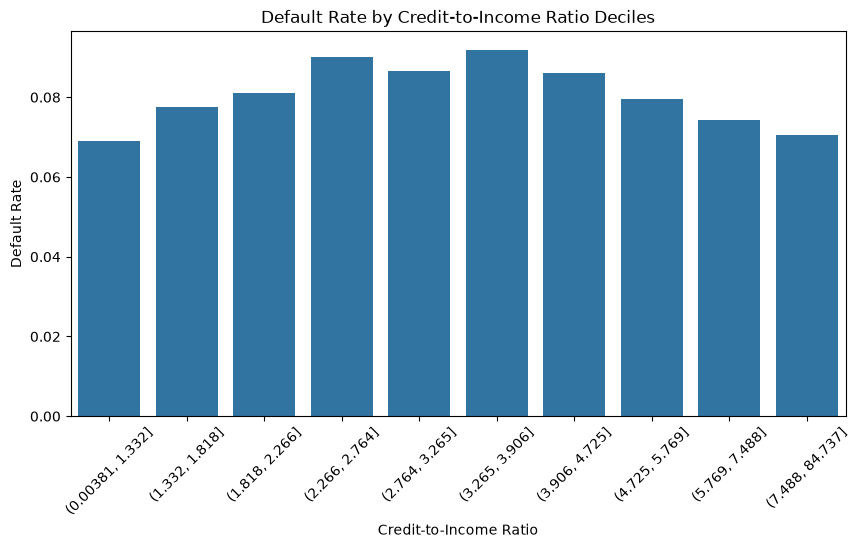

In [14]:
#   Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=credit_income_default,
    x="CREDIT_INCOME_RATIO",
    y="TARGET"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Credit-to-Income Ratio Deciles")
plt.xlabel("Credit-to-Income Ratio")
plt.ylabel("Default Rate")

plt.show()

### Business Interpretation

**Key Observations**

- The Credit-to-Income Ratio exhibits a positively skewed distribution, with most applicants concentrated in the lower ratio range.
- Default rates increase across the lower and middle ratio groups before declining slightly for the highest ratio segment.
- This indicates that the relationship between Credit-to-Income Ratio and default risk is non-linear rather than strictly increasing.

**Credit Risk Perspective**

Applicants requesting loans that represent a moderate proportion of their annual income appear to face greater repayment challenges. Conversely, applicants with extremely high ratios may represent financially stronger borrowers who were approved after more rigorous credit assessment.

The Credit-to-Income Ratio remains an important affordability indicator because it combines two critical financial variables—loan amount and annual income—into a single business-relevant feature that captures borrowing behaviour more effectively than either variable alone.

### 7.6.2 Annuity-to-Income Ratio

The Annuity-to-Income Ratio measures the proportion of an applicant's annual income that is required to meet the annual loan repayment obligation.

This feature serves as an affordability indicator by estimating the financial burden imposed by the loan repayments. Applicants with higher repayment obligations relative to their income may face greater financial stress and an increased probability of default.

In [15]:
# ============================================
# Annuity-to-Income Ratio
# ============================================

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

print(" ANNUITY_INCOME_RATIO created successfully.")

 ANNUITY_INCOME_RATIO created successfully.


### 7.6.3 Credit-to-Annuity Ratio

The Credit-to-Annuity Ratio estimates the relationship between the total loan amount and the annual repayment amount.

Although this is not the exact loan tenure, it provides a useful approximation of the repayment structure. Different repayment profiles may reflect varying levels of credit risk and borrower affordability.

In [16]:
# ============================================
# Credit-to-Annuity Ratio
# ============================================

df["CREDIT_ANNUITY_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_ANNUITY"]
)

print("CREDIT_ANNUITY_RATIO created successfully.")

CREDIT_ANNUITY_RATIO created successfully.


### 7.6.4 Income per Family Member

Total household income does not fully represent an applicant's financial capacity because income is typically shared among family members.

Income per Family Member estimates the amount of income available for each household member and provides a more realistic measure of financial resources.

In [17]:
# ============================================
# Income per Family Member
# ============================================

df["INCOME_PER_FAMILY_MEMBER"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"]
)

print("INCOME_PER_FAMILY_MEMBER created successfully.")

INCOME_PER_FAMILY_MEMBER created successfully.


### 7.6.5 Income per Child

Households with more dependent children generally face higher living expenses.

Income per Child estimates the financial resources available for each dependent child. Adding one to the denominator avoids division-by-zero for households without children.

In [18]:
# ============================================
# Income per Child
# ============================================

df["INCOME_PER_CHILD"] = (
    df["AMT_INCOME_TOTAL"] /
    (df["CNT_CHILDREN"] + 1)
)

print(" INCOME_PER_CHILD created successfully.")

 INCOME_PER_CHILD created successfully.


### 7.6.6 Validation of Financial Features

Before using the engineered features for model development, it is essential to validate their quality.

This validation includes:

- Summary statistics
- Missing value assessment
- Correlation analysis

These checks ensure that the engineered variables are numerically valid and provide meaningful information for predictive modelling.

In [19]:
#Summary Statistics
financial_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD"
]

df[financial_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307511.0,0.180929,0.094573,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_ANNUITY_RATIO,307511.0,21.612366,7.824164,6.324539,15.614473,20.000000,27.099985,5.956035e+01
INCOME_PER_FAMILY_MEMBER,307511.0,93106.335038,101373.313820,2812.500000,47250.000000,75000.000000,112500.000000,3.900000e+07
INCOME_PER_CHILD,307511.0,139507.940778,145811.035192,3000.000000,78750.000000,117000.000000,180000.000000,5.850000e+07


In [20]:
#Missing Values
df[financial_features].isnull().sum()

CREDIT_INCOME_RATIO         0
ANNUITY_INCOME_RATIO        0
CREDIT_ANNUITY_RATIO        0
INCOME_PER_FAMILY_MEMBER    0
INCOME_PER_CHILD            0
dtype: int64

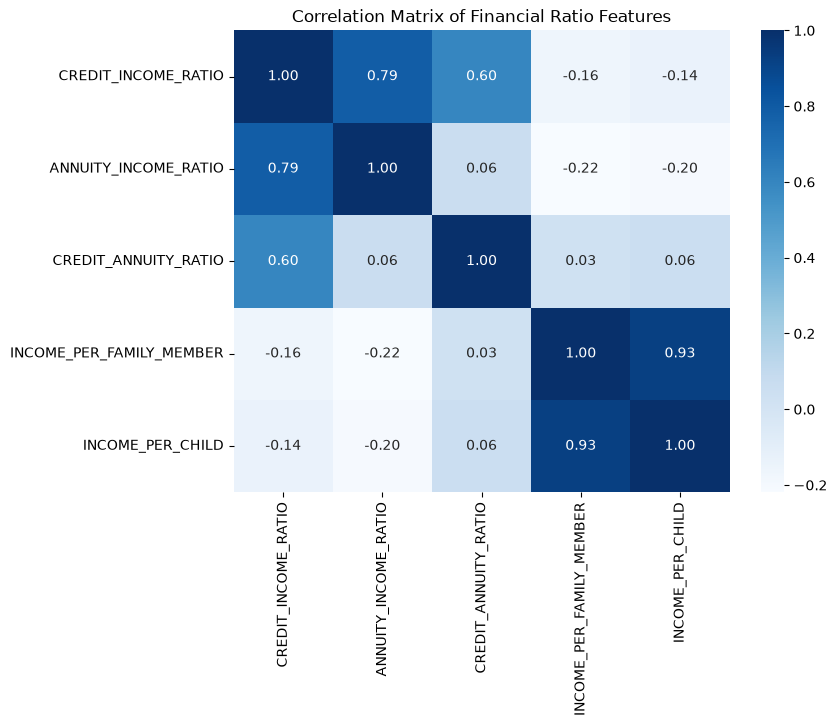

In [21]:
#Correlation Matrix of Financial Ratio Features
plt.figure(figsize=(8,6))

sns.heatmap(
    df[financial_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Financial Ratio Features")

plt.show()

### Validation Summary

The engineered financial ratio features were successfully created without introducing missing values, confirming that the feature engineering process was implemented correctly.

The correlation analysis reveals several important relationships:

- **Credit-to-Income Ratio** and **Annuity-to-Income Ratio** exhibit a strong positive correlation, indicating that applicants requesting larger loans relative to their income also tend to have higher repayment obligations.
- **Credit-to-Annuity Ratio** shows only a moderate correlation with the other financial ratios, suggesting that it captures a different aspect of borrower repayment behaviour.
- **Income per Family Member** and **Income per Child** are highly correlated, as both represent measures of household financial capacity. While they convey similar information, each reflects a distinct household characteristic and may contribute differently to model performance.

Overall, the engineered financial features appear numerically consistent and provide complementary information about borrower affordability, repayment burden, and household financial strength.

### 7.6.7 Distribution Analysis

Understanding the distribution of engineered features is an important step in feature engineering. Distribution analysis helps identify skewness, extreme values, and the overall spread of each feature.

Financial ratio features often exhibit non-normal distributions due to the diverse financial characteristics of loan applicants. Examining these distributions provides valuable insight into borrower affordability, repayment behaviour, and household financial capacity.

The following visualizations assess the distribution of each engineered financial ratio feature.

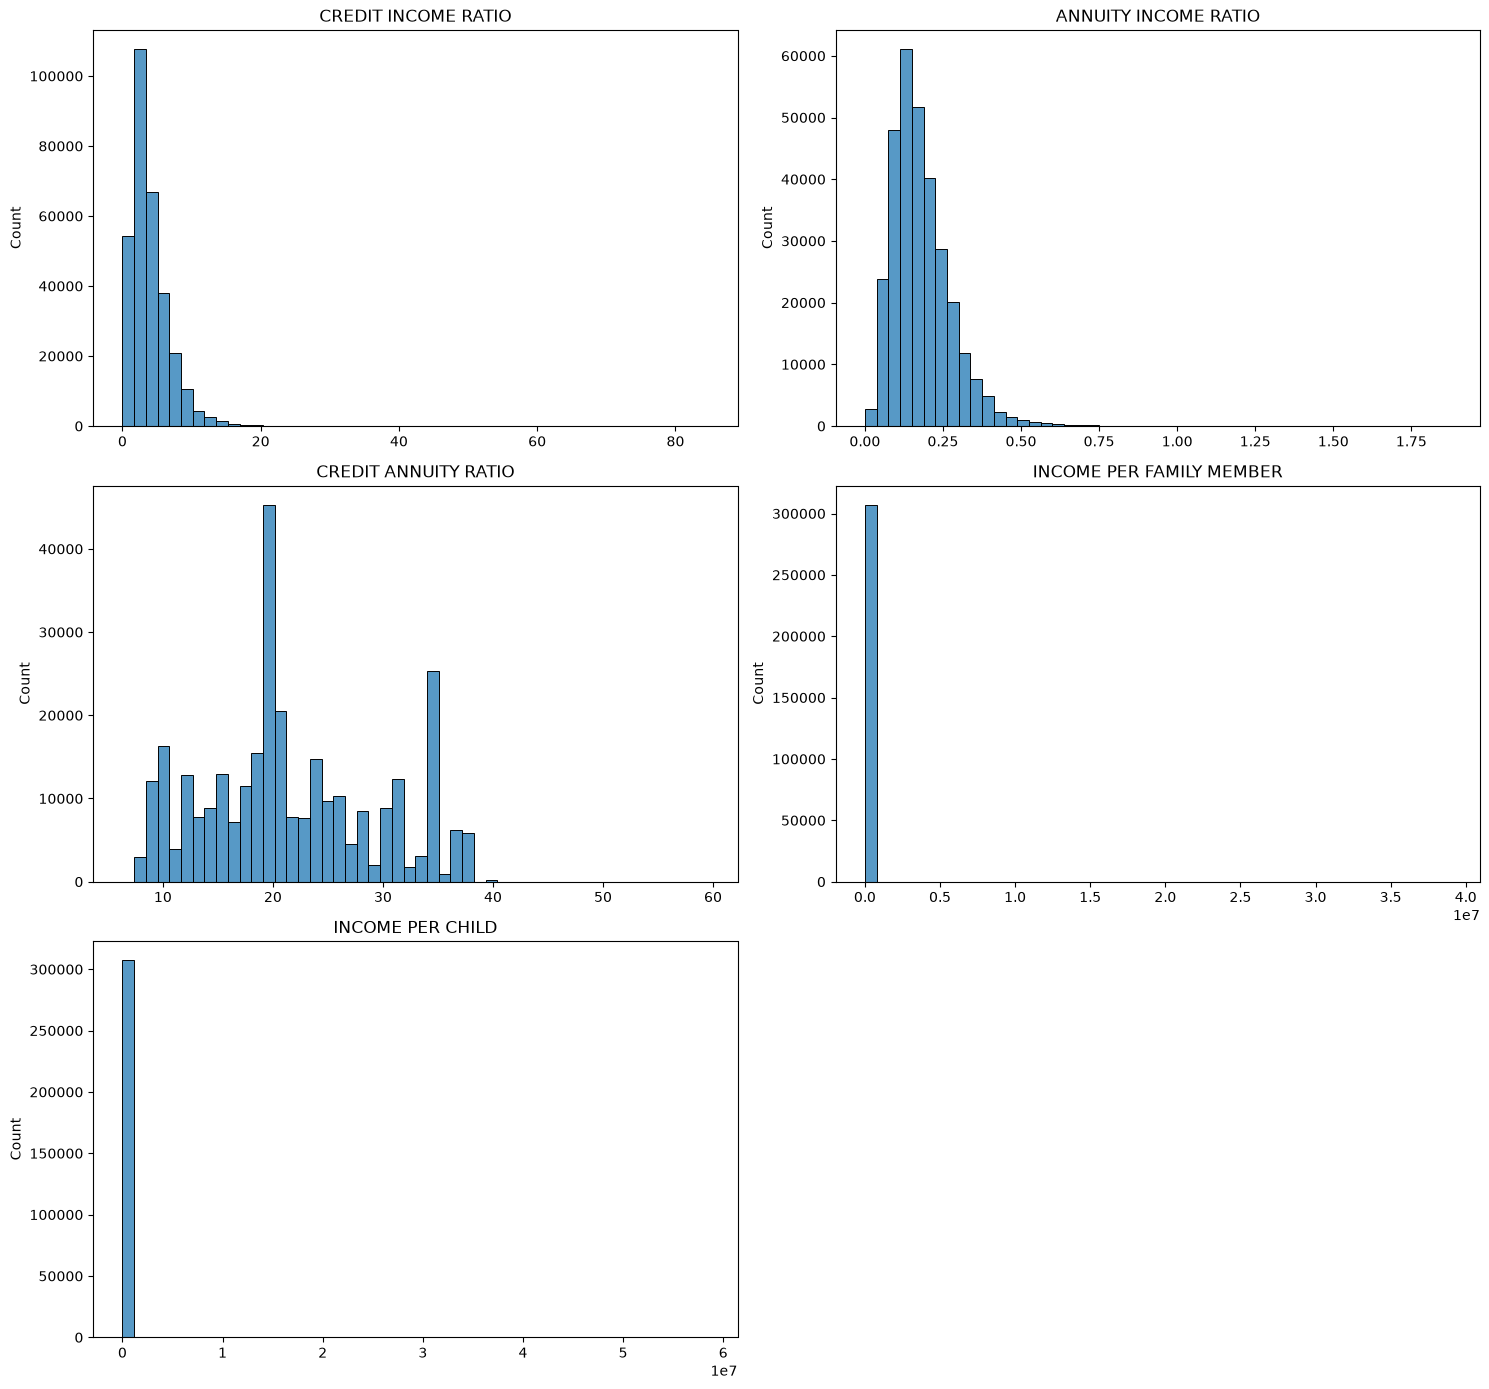

In [22]:
# ============================================
# Distribution of Financial Ratio Features
# ============================================

financial_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))

axes = axes.flatten()

for i, feature in enumerate(financial_features):

    sns.histplot(
        df[feature],
        bins=50,
        ax=axes[i]
    )

    axes[i].set_title(feature.replace("_", " "))
    axes[i].set_xlabel("")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

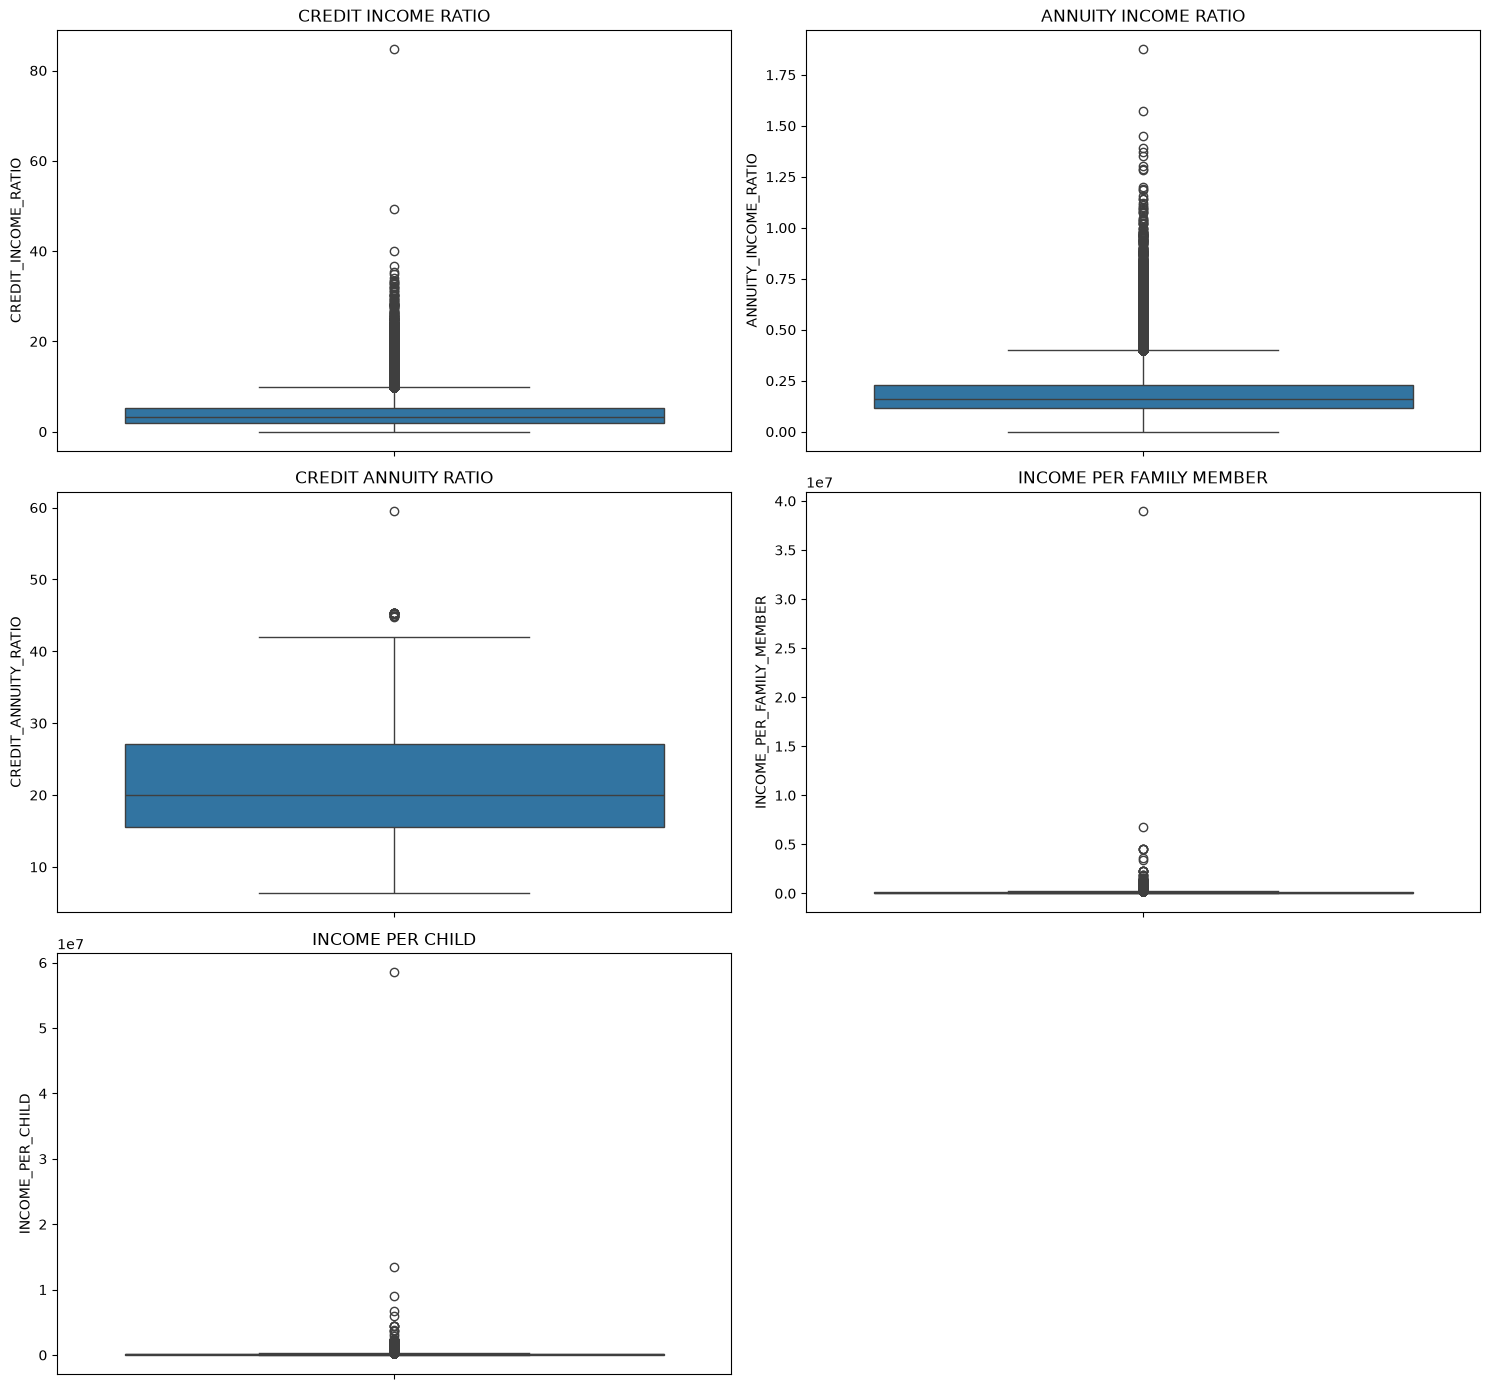

In [23]:
# ============================================
# Boxplots of Financial Ratio Features
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(15, 14))

axes = axes.flatten()

for i, feature in enumerate(financial_features):

    sns.boxplot(
        y=df[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature.replace("_", " "))

fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### Distribution Summary

The distribution analysis demonstrates that the engineered financial ratio features exhibit distinct statistical characteristics rather than following a common pattern.

**Key Observations**

- **Credit-to-Income Ratio** exhibits a pronounced right-skewed distribution. Most applicants request loans that are between one and six times their annual income, while a relatively small number of applicants have substantially higher borrowing levels.
- **Annuity-to-Income Ratio** is also positively skewed, indicating that most applicants allocate a relatively small proportion of their annual income towards loan repayments, with only a limited number facing considerably higher repayment obligations.
- **Credit-to-Annuity Ratio** displays a broader distribution with several concentration points, suggesting that borrowers are associated with different repayment structures and loan tenures rather than a single homogeneous pattern.
- **Income per Family Member** and **Income per Child** contain a small number of extremely large values that compress the majority of observations near the origin. These extreme values are expected for households with exceptionally high income and relatively few dependents.

**Outlier Assessment**

The boxplots confirm the presence of outliers across all engineered financial features. These observations are expected in retail lending data and are more likely to represent genuine borrower behaviour than data quality issues.

**Business Interpretation**

The financial ratio features capture different dimensions of borrower affordability and repayment capacity. Credit-based ratios primarily describe the relationship between borrowing and repayment obligations, whereas income-based ratios measure the financial resources available within a household.

Although several features contain extreme observations, they represent realistic customer profiles rather than erroneous records. Since the subsequent modelling stage will employ tree-based algorithms such as Random Forest, XGBoost, and LightGBM, which are inherently robust to skewed distributions and outliers, these engineered features will be retained without further transformation.

## 7.6.8 Default Rate Analysis

The effectiveness of engineered features can be assessed by examining how loan default rates vary across different feature values.

To facilitate comparison, each financial ratio feature is divided into deciles using equal-frequency binning (`qcut`). The average default rate is then calculated for each decile.

This analysis helps determine whether the engineered financial features are capable of distinguishing between lower-risk and higher-risk borrower groups.

In [24]:
# ============================================
# Default Rate - Credit-to-Income Ratio
# ============================================

credit_income_default = (
    df.groupby(
        pd.qcut(
            df["CREDIT_INCOME_RATIO"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

credit_income_default

,CREDIT_INCOME_RATIO,TARGET
0,"(0.00381, 1.332]",0.069085
1,"(1.332, 1.818]",0.077615
2,"(1.818, 2.266]",0.081126
3,"(2.266, 2.764]",0.090212
4,"(2.764, 3.265]",0.086542
5,"(3.265, 3.906]",0.091962
6,"(3.906, 4.725]",0.086168
7,"(4.725, 5.769]",0.079510
8,"(5.769, 7.488]",0.074412
9,"(7.488, 84.737]",0.070656


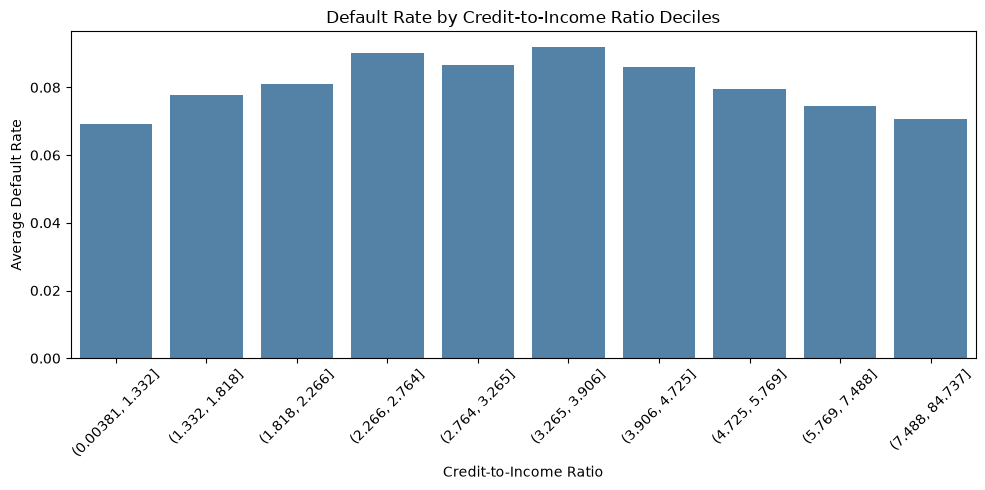

In [25]:
#Visualization 
plt.figure(figsize=(10,5))

sns.barplot(
    data=credit_income_default,
    x="CREDIT_INCOME_RATIO",
    y="TARGET",
    color="steelblue"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Credit-to-Income Ratio Deciles")

plt.xlabel("Credit-to-Income Ratio")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

In [26]:
# ============================================
# Default Rate - Annuity-to-Income Ratio
# ============================================

annuity_income_default = (
    df.groupby(
        pd.qcut(
            df["ANNUITY_INCOME_RATIO"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

annuity_income_default

,ANNUITY_INCOME_RATIO,TARGET
0,"(-0.000776, 0.08]",0.071350
1,"(0.08, 0.104]",0.072646
2,"(0.104, 0.125]",0.078159
3,"(0.125, 0.144]",0.078436
4,"(0.144, 0.163]",0.078771
5,"(0.163, 0.186]",0.083740
6,"(0.186, 0.212]",0.085381
7,"(0.212, 0.247]",0.088541
8,"(0.247, 0.302]",0.088388
9,"(0.302, 1.876]",0.081919


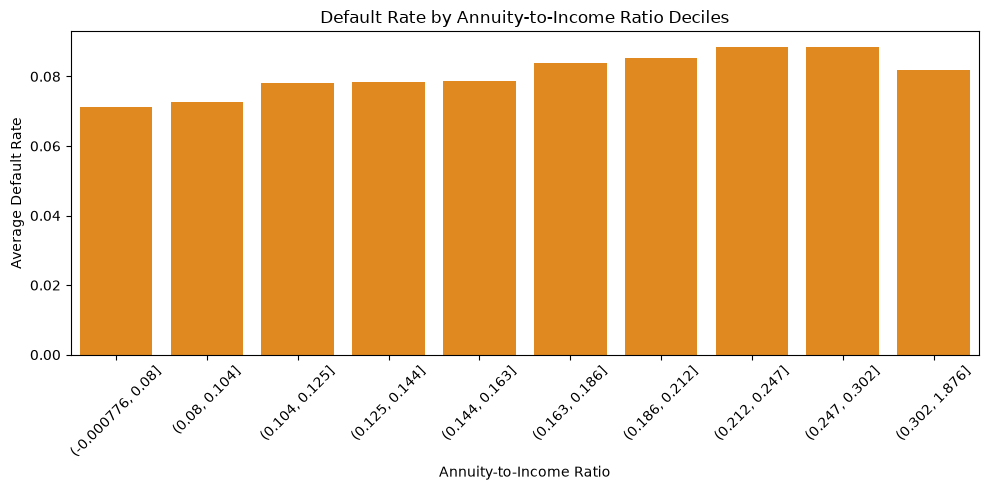

In [27]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=annuity_income_default,
    x="ANNUITY_INCOME_RATIO",
    y="TARGET",
    color="darkorange"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Annuity-to-Income Ratio Deciles")

plt.xlabel("Annuity-to-Income Ratio")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

In [28]:
# ============================================
# Default Rate - Credit-to-Annuity Ratio
# ============================================

credit_annuity_default = (
    df.groupby(
        pd.qcut(
            df["CREDIT_ANNUITY_RATIO"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

credit_annuity_default

,CREDIT_ANNUITY_RATIO,TARGET
0,"(6.324, 10.516]",0.048334
1,"(10.516, 14.63]",0.113157
2,"(14.63, 17.768]",0.099958
3,"(17.768, 19.536]",0.098936
4,"(19.536, 20.0]",0.059822
5,"(20.0, 22.01]",0.142716
6,"(22.01, 25.214]",0.050205
7,"(25.214, 30.143]",0.073389
8,"(30.143, 34.063]",0.071379
9,"(34.063, 59.56]",0.057997


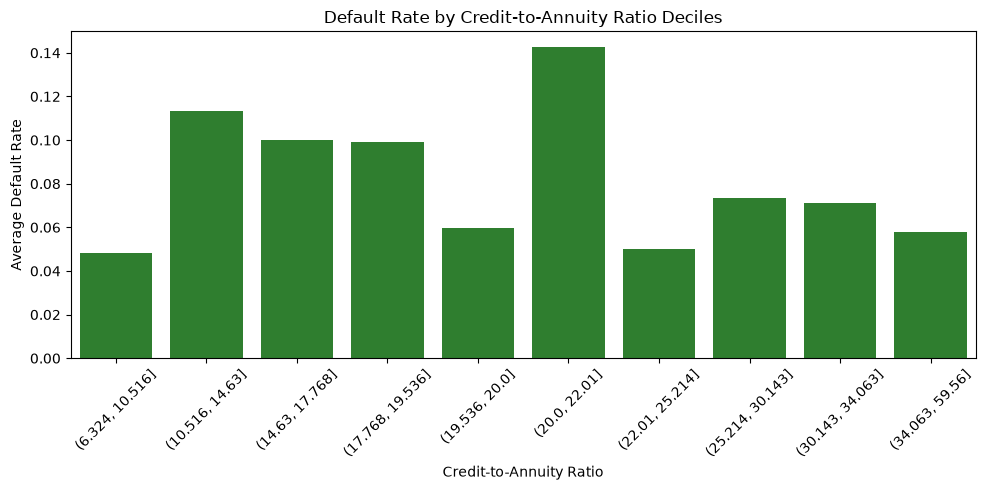

In [29]:
# Visualization 
plt.figure(figsize=(10,5))

sns.barplot(
    data=credit_annuity_default,
    x="CREDIT_ANNUITY_RATIO",
    y="TARGET",
    color="forestgreen"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Credit-to-Annuity Ratio Deciles")

plt.xlabel("Credit-to-Annuity Ratio")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

### Default Rate Analysis

The default rate analysis evaluates whether the engineered financial ratio features effectively differentiate between lower-risk and higher-risk borrowers.

**Key Observations**

- **Credit-to-Income Ratio:** The default rate increases from the lower deciles and reaches its highest level in the middle-to-upper deciles before gradually declining for the highest ratio groups. This suggests that the relationship between borrowing relative to income and default risk is non-linear.

- **Annuity-to-Income Ratio:** A generally increasing trend is observed across the deciles. Applicants allocating a larger proportion of their income towards loan repayments tend to exhibit higher default rates, indicating that repayment burden is an important indicator of financial stress.

- **Credit-to-Annuity Ratio:** The default pattern is considerably more variable across the deciles. Although certain repayment structures are associated with elevated default rates, the relationship is less consistent than that observed for the income-based affordability ratios.

**Business Interpretation**

Among the engineered financial features, the **Annuity-to-Income Ratio** demonstrates the clearest relationship with default risk, suggesting that repayment affordability is a strong predictor of loan performance.

The **Credit-to-Income Ratio** also provides valuable predictive information, although its relationship with default risk is non-linear, indicating that additional borrower characteristics and underwriting decisions influence loan performance.

The **Credit-to-Annuity Ratio** captures complementary information regarding loan repayment structure and should be retained, as it may contribute additional predictive value when combined with other engineered features within machine learning models.

### 7.6.9 Key Business Insights

The financial ratio features engineered in this section provide a more comprehensive representation of an applicant's financial position than the original variables alone.

**Key Findings**

- Ratio-based features effectively capture borrower affordability by combining income, credit amount, and repayment obligations into meaningful financial indicators.
- The Annuity-to-Income Ratio exhibits the strongest relationship with default risk, highlighting the importance of repayment burden in predicting loan performance.
- The Credit-to-Income Ratio provides additional insight into borrower leverage and demonstrates a non-linear relationship with default risk, suggesting that lending decisions are influenced by multiple financial factors.
- The Credit-to-Annuity Ratio contributes complementary information regarding loan repayment structure and may improve predictive performance when combined with other engineered variables.
- Income-based household features (Income per Family Member and Income per Child) offer additional context on household financial capacity and may capture differences in living standards and financial obligations.

**Business Value**

From a credit risk perspective, these engineered financial features transform raw monetary variables into business-oriented indicators that better represent repayment capacity, affordability, and financial stress.

These features are expected to improve the model's ability to distinguish between low-risk and high-risk applicants while enhancing the interpretability of the credit risk assessment process.

## 7.7 Employment Features

Employment characteristics provide valuable information about an applicant's financial stability and repayment capacity. While variables such as employment duration and age are informative individually, combining them into business-driven features often provides stronger predictive signals.

In this section, we engineer employment-related features that measure work experience, employment stability, and career maturity. These features are expected to improve the model's ability to distinguish between borrowers with stable employment histories and those with limited work experience.

### 7.7.1 Employment-to-Age Ratio

Employment duration alone does not fully describe an applicant's work experience because it does not account for age differences.

The Employment-to-Age Ratio measures the proportion of an applicant's lifetime spent in employment. Applicants who have spent a larger share of their working life employed are generally expected to exhibit greater financial stability and more consistent repayment behaviour.

In [30]:
# ============================================
# Employment-to-Age Ratio
# ============================================

df["EMPLOYMENT_AGE_RATIO"] = (
    df["EMPLOYMENT_YEARS"] /
    df["AGE_YEARS"]
)

print(" EMPLOYMENT_AGE_RATIO created successfully.")

 EMPLOYMENT_AGE_RATIO created successfully.


### 7.7.2 Employment Experience Category

Applicants are grouped according to their years of employment experience.

These categories represent different career stages and help the model capture non-linear relationships between work experience and default risk.

In [31]:
# ============================================
# Employment Experience Category
# ============================================

experience_bins = [
    0,
    2,
    5,
    10,
    20,
    np.inf
]

experience_labels = [
    "0-2 Years",
    "2-5 Years",
    "5-10 Years",
    "10-20 Years",
    "20+ Years"
]

df["EMPLOYMENT_CATEGORY"] = pd.cut(
    df["EMPLOYMENT_YEARS"],
    bins=experience_bins,
    labels=experience_labels
)

print(" EMPLOYMENT_CATEGORY created successfully.")

 EMPLOYMENT_CATEGORY created successfully.


### 7.7.3 Validation of Employment Features

The engineered employment features are validated to ensure they have been created correctly and provide meaningful information for subsequent modelling.

The validation includes:

- Summary statistics
- Missing value assessment
- Employment category distribution
- Correlation analysis

In [32]:
#Summary Statistics
employment_features = [
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO"
]

df[employment_features].describe().T

,count,mean,std,min,25%,50%,75%,max
EMPLOYMENT_YEARS,252137.0,6.527498,6.402080,0.0,2.100000,4.51000,8.690000,49.040000
EMPLOYMENT_AGE_RATIO,252137.0,0.156861,0.133549,0.0,0.056109,0.11875,0.219165,0.728678


In [33]:
#Missing Values 
df[
    employment_features +
    ["EMPLOYMENT_CATEGORY"]
].isnull().sum()

EMPLOYMENT_YEARS        55374
EMPLOYMENT_AGE_RATIO    55374
EMPLOYMENT_CATEGORY     55377
dtype: int64

In [34]:
#Employment Category Distribution
df["EMPLOYMENT_CATEGORY"].value_counts().sort_index()

EMPLOYMENT_CATEGORY
0-2 Years      59980
2-5 Years      76457
5-10 Years     64835
10-20 Years    38342
20+ Years      12520
Name: count, dtype: int64

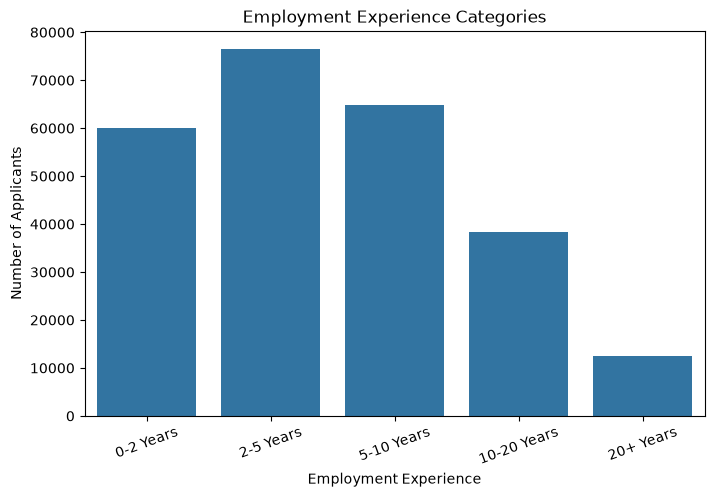

In [35]:
# Countplot Visualization 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="EMPLOYMENT_CATEGORY",
    order=experience_labels
)

plt.title("Employment Experience Categories")

plt.xlabel("Employment Experience")

plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.show()

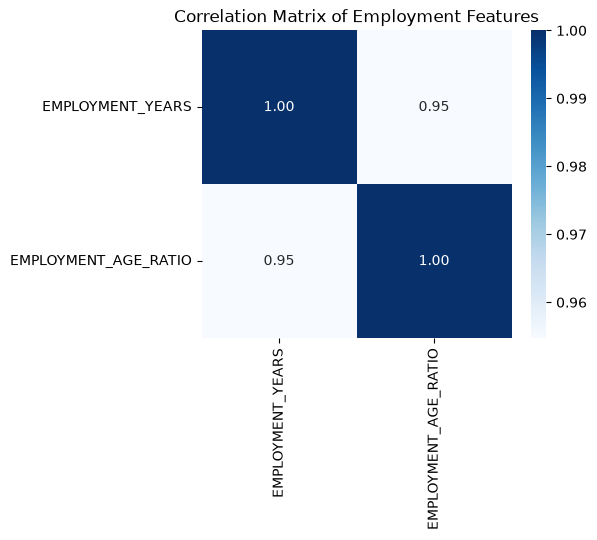

In [36]:
# Correlation Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    df[employment_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Employment Features")

plt.show()

### Validation Summary

The engineered employment features were successfully created using the cleaned employment information from Notebook 03.

**Key Observations**

- The average employment duration is approximately **6.5 years**, indicating that most applicants possess several years of work experience.
- The average Employment-to-Age Ratio is approximately **0.16**, suggesting that applicants have spent, on average, around 16% of their lifetime in recorded employment.
- Approximately **55,000 applicants** have missing employment-related information. These missing values originate from unavailable employment records rather than errors introduced during feature engineering.
- The Employment Experience Category distribution shows that most applicants fall within the **2–5 years** and **5–10 years** experience groups, while relatively few applicants have more than **20 years** of employment experience.
- The correlation coefficient between **Employment Years** and **Employment-to-Age Ratio** is **0.95**, indicating a very strong positive relationship. This is expected because the ratio is derived directly from employment duration and applicant age.

**Business Interpretation**

The engineered employment features provide complementary information regarding an applicant's career maturity and work experience. Although the two numerical features are highly correlated, they represent different perspectives of employment history and may contribute differently during model training.

The missing employment values represent applicants with unavailable employment information and will be retained for appropriate handling during the modelling stage.

### 7.7.4 Distribution Analysis

Understanding the distribution of engineered employment features helps assess their variability, identify potential outliers, and evaluate whether they capture meaningful differences across applicants.

Since **Employment Experience Category** is a categorical feature and has already been examined through its frequency distribution, this section focuses on the numerical feature **Employment-to-Age Ratio**.

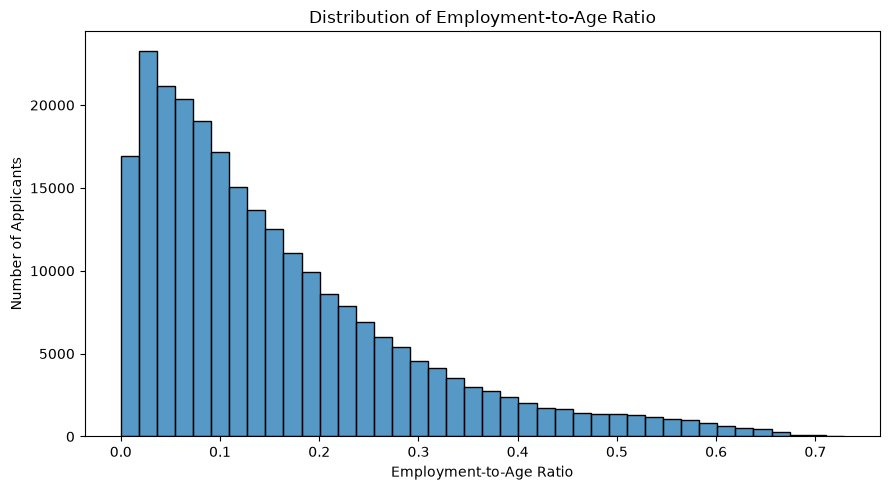

In [37]:
# ============================================
# Distribution of Employment-to-Age Ratio (Histogram)
# ============================================

plt.figure(figsize=(9,5))

sns.histplot(
    df["EMPLOYMENT_AGE_RATIO"],
    bins=40
)

plt.title("Distribution of Employment-to-Age Ratio")
plt.xlabel("Employment-to-Age Ratio")
plt.ylabel("Number of Applicants")

plt.tight_layout()

plt.show()

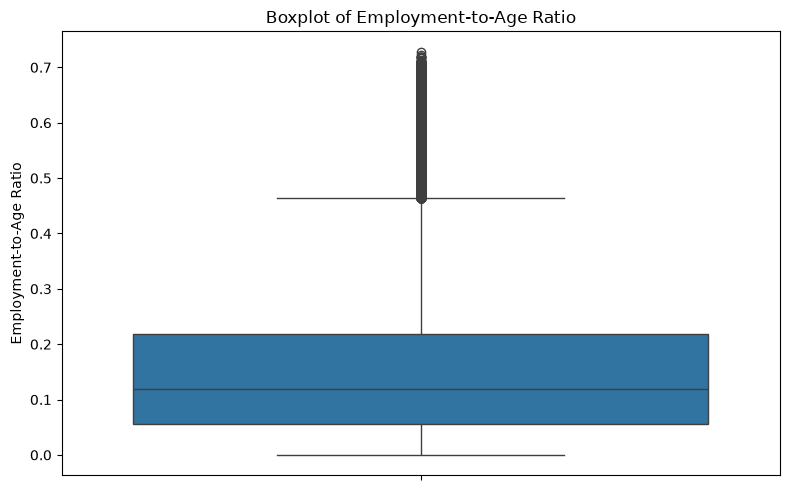

In [38]:
# ============================================
# Boxplot of Employment-to-Age Ratio (Countplot)
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["EMPLOYMENT_AGE_RATIO"]
)

plt.title("Boxplot of Employment-to-Age Ratio")
plt.ylabel("Employment-to-Age Ratio")

plt.tight_layout()

plt.show()

### Distribution Summary

The distribution of the **Employment-to-Age Ratio** provides insight into the proportion of an applicant's lifetime spent in employment.

**Key Observations**

- The Employment-to-Age Ratio exhibits a positively skewed distribution, with the majority of applicants concentrated in the lower ratio range.
- Most applicants have spent less than **25% of their lifetime** in recorded employment, while relatively few applicants exhibit substantially higher employment ratios.
- The boxplot identifies several high-value observations above the upper whisker, indicating the presence of applicants with exceptionally long employment histories relative to their age.
- Despite these outliers, the majority of observations remain concentrated within a relatively narrow range, suggesting a consistent employment profile across most applicants.

**Business Interpretation**

Applicants with higher Employment-to-Age Ratios generally have longer and potentially more stable employment histories relative to their age, reflecting greater career maturity and financial stability. Conversely, lower ratios may correspond to younger applicants, individuals with interrupted employment histories, or applicants with limited work experience.

The observed outliers are considered realistic representations of borrower characteristics rather than data quality issues. Since tree-based machine learning algorithms are robust to skewed distributions and extreme values, the engineered Employment-to-Age Ratio will be retained without additional transformation.

### 7.7.5 Default Rate Analysis

The predictive value of the engineered employment features is evaluated by examining how loan default rates vary across different employment groups.

For the numerical feature **Employment-to-Age Ratio**, applicants are divided into equal-frequency deciles using `qcut()`. For the categorical feature **Employment Experience Category**, the average default rate is calculated for each experience group.

This analysis helps determine whether employment-related features effectively differentiate between lower-risk and higher-risk borrowers.

In [39]:
# ============================================
# Default Rate - Employment-to-Age Ratio
# ============================================

employment_ratio_default = (
    df.groupby(
        pd.qcut(
            df["EMPLOYMENT_AGE_RATIO"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

employment_ratio_default

,EMPLOYMENT_AGE_RATIO,TARGET
0,"(-0.001, 0.0243]",0.105259
1,"(0.0243, 0.0451]",0.110018
2,"(0.0451, 0.0673]",0.106691
3,"(0.0673, 0.0912]",0.102157
4,"(0.0912, 0.119]",0.094179
5,"(0.119, 0.152]",0.086960
6,"(0.152, 0.193]",0.078567
7,"(0.193, 0.25]",0.068020
8,"(0.25, 0.345]",0.065123
9,"(0.345, 0.729]",0.049020


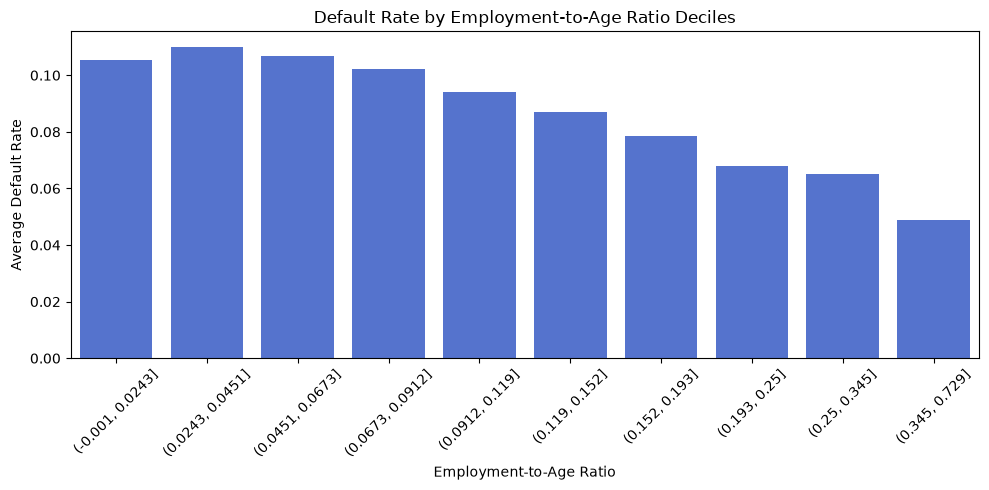

In [41]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=employment_ratio_default,
    x="EMPLOYMENT_AGE_RATIO",
    y="TARGET",
    color="royalblue"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Employment-to-Age Ratio Deciles")

plt.xlabel("Employment-to-Age Ratio")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

In [42]:
# ============================================
# Default Rate - Employment Experience Category
# ============================================

employment_category_default = (
    df.groupby("EMPLOYMENT_CATEGORY")["TARGET"]
    .mean()
    .reset_index()
)

employment_category_default

,EMPLOYMENT_CATEGORY,TARGET
0,0-2 Years,0.112054
1,2-5 Years,0.100671
2,5-10 Years,0.073710
3,10-20 Years,0.055109
4,20+ Years,0.041853


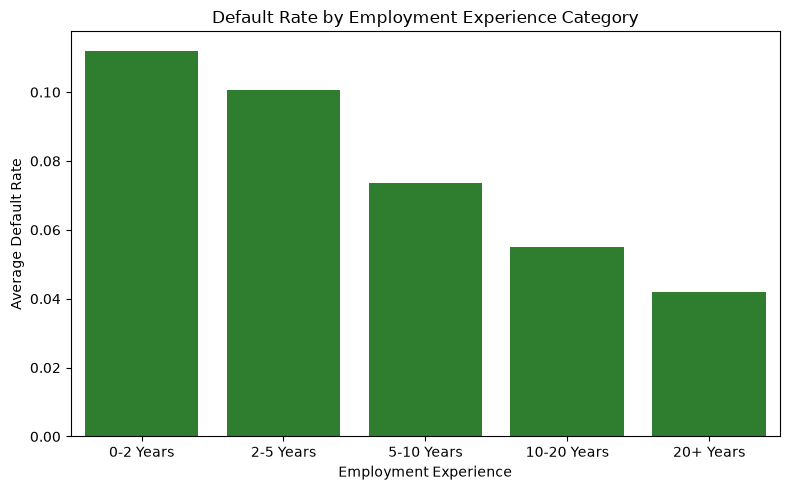

In [43]:
#Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    data=employment_category_default,
    x="EMPLOYMENT_CATEGORY",
    y="TARGET",
    order=experience_labels,
    color="forestgreen"
)

plt.title("Default Rate by Employment Experience Category")

plt.xlabel("Employment Experience")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

### Default Rate Analysis

The engineered employment features were evaluated by comparing average loan default rates across different employment groups.

**Key Observations**

- **Employment-to-Age Ratio:** A clear inverse relationship is observed between the Employment-to-Age Ratio and default risk. Applicants with lower employment ratios exhibit the highest default rates, while default rates decline steadily as the proportion of lifetime spent in employment increases.

- **Employment Experience Category:** Default rates decrease consistently as employment experience increases. Applicants with **0–2 years** of employment experience exhibit the highest default rate (approximately **11.2%**), whereas applicants with **20+ years** of employment experience show the lowest default rate (approximately **4.2%**).

- Both engineered employment features demonstrate a strong and consistent relationship with loan default, indicating that employment history is an important determinant of creditworthiness.

**Business Interpretation**

Applicants with longer employment histories generally demonstrate greater financial stability, more consistent income, and lower repayment uncertainty. Consequently, these borrowers exhibit substantially lower default rates than applicants with limited work experience.

The clear monotonic decline in default rates across both employment features suggests that employment history is a powerful predictor of credit risk. These engineered variables are therefore expected to contribute meaningful predictive information and improve the performance of subsequent machine learning models.

### 7.7.6 Key Business Insights

The engineered employment features substantially enhance the representation of an applicant's career history and financial stability beyond the original employment variables.

**Key Findings**

- The Employment-to-Age Ratio effectively captures career maturity by measuring the proportion of an applicant's lifetime spent in employment.
- Employment Experience Category identifies meaningful career stages and reveals a clear decline in default risk as employment experience increases.
- Both engineered employment features exhibit strong and consistent relationships with loan default, demonstrating their predictive value for credit risk assessment.

**Business Value**

Employment history is one of the most informative indicators of borrower stability. Applicants with longer and more established employment histories generally exhibit lower repayment risk due to greater income stability and accumulated work experience.

These engineered employment features are expected to improve model performance while enhancing the interpretability of credit risk predictions by providing intuitive measures of career maturity and employment stability.

## 7.8 Credit History Features

Credit history and repayment-related characteristics are among the strongest predictors of loan default. While the original dataset provides several variables describing credit exposure and external credit bureau assessments, engineered features can better capture borrower affordability, repayment structure, and overall creditworthiness.

In this section, we construct business-oriented credit history features that summarize loan characteristics and external credit risk information. These engineered variables are expected to provide substantial predictive value for the subsequent machine learning models.

In [44]:
credit_columns = [
    col for col in df.columns
    if any(keyword in col for keyword in [
        "AMT_",
        "EXT_SOURCE",
        "CREDIT",
        "ANNUITY"
    ])
]

sorted(credit_columns)

['AMT_ANNUITY',
 'AMT_CREDIT',
 'AMT_GOODS_PRICE',
 'AMT_INCOME_TOTAL',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_ANNUITY_RATIO',
 'CREDIT_INCOME_RATIO',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3']

### 7.8.1 Credit Term

Loan amount and loan annuity individually provide useful information; however, combining these variables allows us to estimate the effective repayment duration of the loan.

The Credit Term feature is calculated as the ratio of the total credit amount to the loan annuity. Larger values generally indicate longer repayment periods.

In [46]:
# ============================================
# Credit Term
# ============================================

df["CREDIT_TERM"] = (
    df["AMT_CREDIT"] /
    df["AMT_ANNUITY"]
)

print(" CREDIT_TERM created successfully.")

 CREDIT_TERM created successfully.


### 7.8.2 Loan-to-Goods Price Ratio

The Loan-to-Goods Price Ratio measures the proportion of the purchased asset financed through credit.

Applicants financing a larger share of the asset value through borrowing may exhibit different repayment behaviour compared with applicants contributing a larger personal down payment.

In [47]:
# ============================================
# Loan-to-Goods Price Ratio
# ============================================

df["LOAN_GOODS_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_GOODS_PRICE"]
)

print(" LOAN_GOODS_RATIO created successfully.")

 LOAN_GOODS_RATIO created successfully.


### 7.8.3 Average External Risk Score

The Home Credit dataset contains three external credit risk scores obtained from independent sources.

Rather than evaluating these scores separately, we compute their average to create a single, more robust indicator of overall applicant creditworthiness.

In [48]:
# ============================================
# Average External Risk Score
# ============================================

df["AVG_EXT_SOURCE"] = (
    df[
        [
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3"
        ]
    ]
    .mean(axis=1)
)

print(" AVG_EXT_SOURCE created successfully.")

 AVG_EXT_SOURCE created successfully.


### 7.8.4 External Risk Category

To improve business interpretability, the average external risk score is grouped into risk categories using quartiles.

These categories allow borrowers to be classified into relative credit risk groups while preserving the underlying ranking of external credit scores.

In [49]:
# ============================================
# External Risk Category
# ============================================

risk_labels = [
    "Very High Risk",
    "High Risk",
    "Low Risk",
    "Very Low Risk"
]

df["EXT_RISK_CATEGORY"] = pd.qcut(
    df["AVG_EXT_SOURCE"],
    q=4,
    labels=risk_labels,
    duplicates="drop"
)

print(" EXT_RISK_CATEGORY created successfully.")

 EXT_RISK_CATEGORY created successfully.


### 7.8.5 Validation of Credit History Features

The engineered credit history features are validated to ensure they have been created correctly and provide meaningful information for subsequent modelling.

The validation includes:

- Summary statistics
- Missing value assessment
- Category distribution
- Correlation analysis

In [51]:
#Summary Statistics
credit_features = [
    "CREDIT_TERM",
    "LOAN_GOODS_RATIO",
    "AVG_EXT_SOURCE"
]

df[credit_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_TERM,307511.0,21.612366,7.824164,6.324539,15.614473,20.000000,27.099985,59.560354
LOAN_GOODS_RATIO,307511.0,1.122542,0.125542,0.150000,1.000000,1.118800,1.198000,6.000000
AVG_EXT_SOURCE,307511.0,0.511503,0.108104,0.023705,0.441604,0.521564,0.587715,0.853417


In [53]:
#Missing Value
df[
    credit_features +
    ["EXT_RISK_CATEGORY"]
].isnull().sum()

CREDIT_TERM          0
LOAN_GOODS_RATIO     0
AVG_EXT_SOURCE       0
EXT_RISK_CATEGORY    0
dtype: int64

In [54]:
#External Risk Category Distribution
df["EXT_RISK_CATEGORY"].value_counts().sort_index()

EXT_RISK_CATEGORY
Very High Risk    76879
High Risk         76877
Low Risk          76877
Very Low Risk     76878
Name: count, dtype: int64

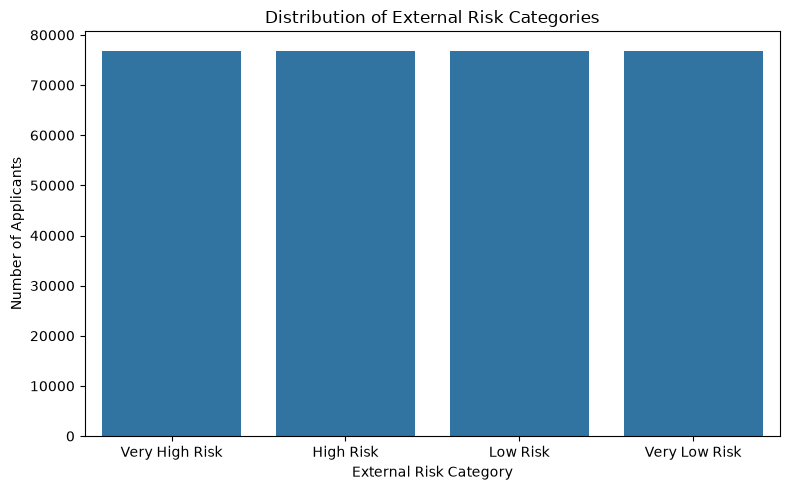

In [55]:
#Countplot Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="EXT_RISK_CATEGORY",
    order=risk_labels
)

plt.title("Distribution of External Risk Categories")

plt.xlabel("External Risk Category")

plt.ylabel("Number of Applicants")

plt.tight_layout()

plt.show()

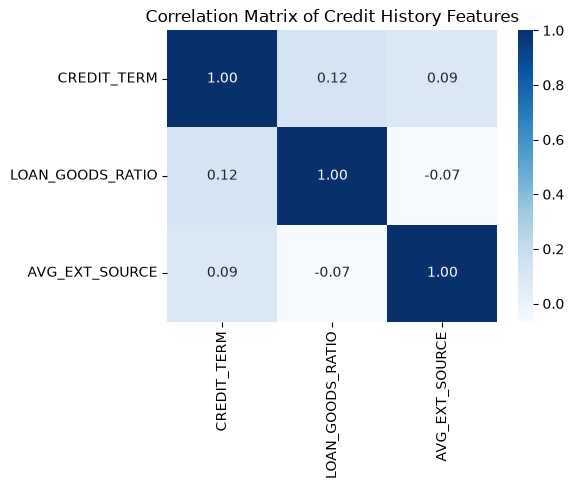

In [56]:
#Correlation Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    df[credit_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Credit History Features")

plt.tight_layout()

plt.show()

### Business Interpretation

The engineered credit history features successfully capture multiple dimensions of borrower credit behaviour.

**Key Findings**

- All engineered credit history features were created successfully with no missing values.
- The External Risk Categories are evenly distributed because quartile-based segmentation was applied, allowing balanced comparisons across applicant groups.
- The correlation matrix indicates weak relationships among the engineered features, suggesting that each feature contributes unique information regarding borrower risk.

**Business Interpretation**

Credit Term reflects the repayment horizon of a loan, Loan-to-Goods Ratio measures financing relative to asset value, and the Average External Score summarizes historical creditworthiness from external sources. Since these variables measure different aspects of credit behaviour, they complement one another and are expected to improve the predictive performance of machine learning models without introducing significant redundancy.

## 7.9 Time-Based Features

### 7.9.1 Applicant Age Category

Applicant age is transformed into business-friendly categories that represent different stages of an individual's financial life cycle.

These categories can help identify variations in default behaviour across younger, middle-aged, and older borrowers.

In [58]:
age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["AGE_CATEGORY"] = pd.cut(
    df["AGE_YEARS"],
    bins=[18,25,35,45,55,100],
    labels=age_labels,
    include_lowest=True
)

print("Feature Created Successfully!")

df["AGE_CATEGORY"].value_counts().sort_index()

Feature Created Successfully!


AGE_CATEGORY
18-25    12428
26-35    72605
36-45    83969
46-55    70457
56+      68052
Name: count, dtype: int64

In [60]:
#Validation 
df["AGE_CATEGORY"].head()

0    26-35
1    46-55
2    46-55
3    46-55
4    46-55
Name: AGE_CATEGORY, dtype: category
Categories (5, str): ['18-25' < '26-35' < '36-45' < '46-55' < '56+']

### 7.9.2 Years Since Registration

The registration period measures how long an applicant has been registered at their current residence.

Longer registration periods generally indicate greater residential stability, which may be associated with lower credit risk.

In [61]:
df["REGISTRATION_YEARS"] = (
    abs(df["DAYS_REGISTRATION"]) / 365
)

print("Feature Created Successfully!")

df["REGISTRATION_YEARS"].describe()

Feature Created Successfully!


count    307511.000000
mean         13.660604
std           9.651743
min           0.000000
25%           5.506849
50%          12.339726
75%          20.491781
max          67.594521
Name: REGISTRATION_YEARS, dtype: float64

In [62]:
#Validation
df["REGISTRATION_YEARS"].head()

0     9.994521
1     3.249315
2    11.671233
3    26.939726
4    11.810959
Name: REGISTRATION_YEARS, dtype: float64

### 7.9.3 Years Since ID Change

The number of years since the last identity document change provides information about applicant stability and document history.

Applicants with frequent identity changes may exhibit different behavioural characteristics compared to those with long-standing documentation.

In [63]:
df["ID_CHANGE_YEARS"] = (
    abs(df["DAYS_ID_PUBLISH"]) / 365
)

print("Feature Created Successfully!")

df["ID_CHANGE_YEARS"].describe()

Feature Created Successfully!


count    307511.000000
mean          8.203294
std           4.135481
min           0.000000
25%           4.712329
50%           8.915068
75%          11.778082
max          19.717808
Name: ID_CHANGE_YEARS, dtype: float64

In [64]:
#Validation
df["ID_CHANGE_YEARS"].head()

0    5.808219
1    0.797260
2    6.934247
3    6.676712
4    9.473973
Name: ID_CHANGE_YEARS, dtype: float64

### 7.9.4 Years Since Last Phone Change

Phone number stability can serve as a behavioural indicator of customer consistency.

Applicants who frequently change contact information may exhibit different credit risk profiles compared to those maintaining long-term contact details.

In [65]:
df["PHONE_CHANGE_YEARS"] = (
    abs(df["DAYS_LAST_PHONE_CHANGE"]) / 365
)

print("Feature Created Successfully!")

df["PHONE_CHANGE_YEARS"].describe()

Feature Created Successfully!


count    307511.000000
mean          2.637967
std           2.265225
min           0.000000
25%           0.750685
50%           2.073973
75%           4.301370
max          11.758904
Name: PHONE_CHANGE_YEARS, dtype: float64

In [66]:
#Validation
df["PHONE_CHANGE_YEARS"].head()

0    3.106849
1    2.268493
2    2.232877
3    1.690411
4    3.030137
Name: PHONE_CHANGE_YEARS, dtype: float64

### 7.9.5 Validation of Time-Based Features

The engineered time-based features are validated to ensure they have been created correctly and contain meaningful information for subsequent predictive modelling.

The validation includes:

- Summary statistics
- Missing value assessment
- Category distribution
- Correlation analysis

In [67]:
#Summary Statistics
time_features = [
    "REGISTRATION_YEARS",
    "ID_CHANGE_YEARS",
    "PHONE_CHANGE_YEARS"
]

df[
    time_features
].describe().T

,count,mean,std,min,25%,50%,75%,max
REGISTRATION_YEARS,307511.0,13.660604,9.651743,0.0,5.506849,12.339726,20.491781,67.594521
ID_CHANGE_YEARS,307511.0,8.203294,4.135481,0.0,4.712329,8.915068,11.778082,19.717808
PHONE_CHANGE_YEARS,307511.0,2.637967,2.265225,0.0,0.750685,2.073973,4.301370,11.758904


In [68]:
#Missing Values
df[
    time_features +
    ["AGE_CATEGORY"]
].isnull().sum()

REGISTRATION_YEARS    0
ID_CHANGE_YEARS       0
PHONE_CHANGE_YEARS    0
AGE_CATEGORY          0
dtype: int64

In [69]:
#Age Category Distribution
df["AGE_CATEGORY"].value_counts().sort_index()

AGE_CATEGORY
18-25    12428
26-35    72605
36-45    83969
46-55    70457
56+      68052
Name: count, dtype: int64

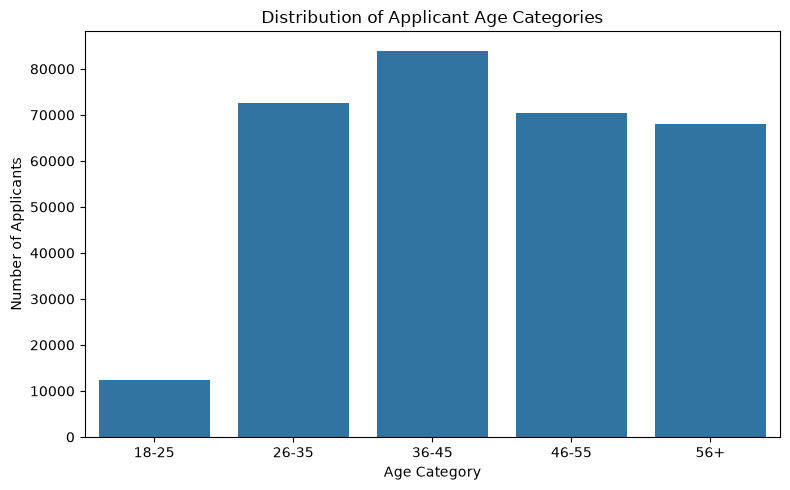

In [70]:
#Countplot Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AGE_CATEGORY",
    order=age_labels
)

plt.title("Distribution of Applicant Age Categories")

plt.xlabel("Age Category")

plt.ylabel("Number of Applicants")

plt.tight_layout()

plt.show()

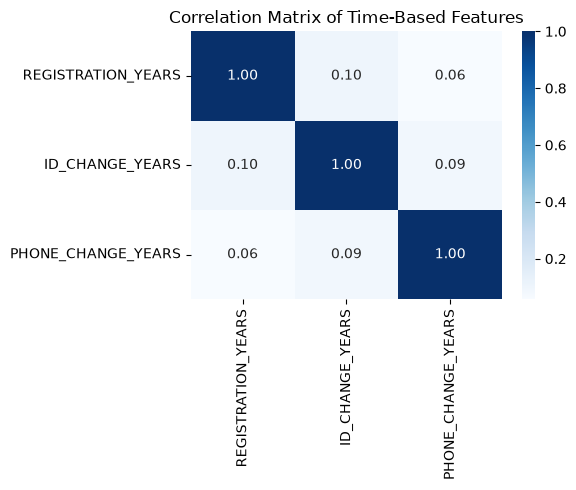

In [71]:
#Correlation Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    df[time_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Time-Based Features")

plt.tight_layout()

plt.show()

### Business Interpretation

The engineered time-based features successfully capture multiple dimensions of applicant stability over time.

**Key Findings**

- All engineered features were created successfully without missing values.
- Most applicants belong to the middle-age categories (26–55 years), representing the primary borrowing population.
- Registration history, identity document history, and phone change history exhibit only weak correlations, indicating that each feature contributes distinct behavioural information.

**Business Interpretation**

Long-term residential stability, infrequent identity document updates, and consistent contact information often reflect stable customer behaviour. These characteristics are valuable indicators in credit risk assessment because they may be associated with stronger repayment reliability. The low correlation among these features suggests they provide complementary signals that can improve predictive performance without introducing substantial redundancy.

### 7.9.6 Distribution Analysis

The distributions of the engineered time-based features are examined to understand their variability, skewness, and the presence of extreme observations.

Since these variables capture different aspects of applicant stability over time, their distributions provide useful insights into customer behaviour before model development.

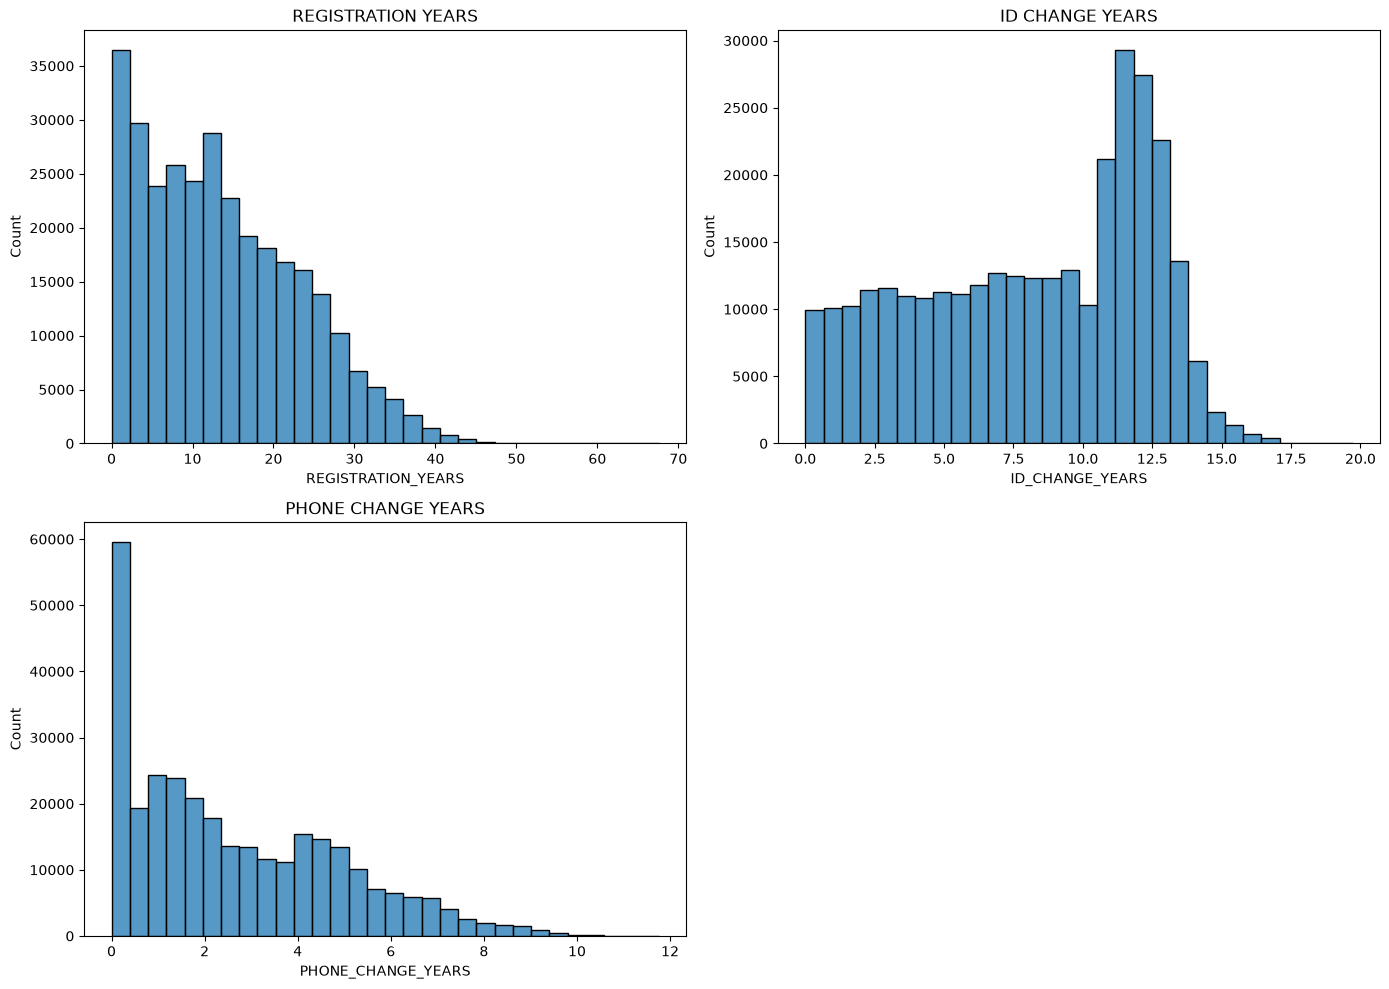

In [72]:
#Histogram
time_features = [
    "REGISTRATION_YEARS",
    "ID_CHANGE_YEARS",
    "PHONE_CHANGE_YEARS"
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, feature in enumerate(time_features):

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        ax=axes[i]
    )

    axes[i].set_title(feature.replace("_", " "))

# Remove empty subplot
fig.delaxes(axes[3])

plt.tight_layout()

plt.show()

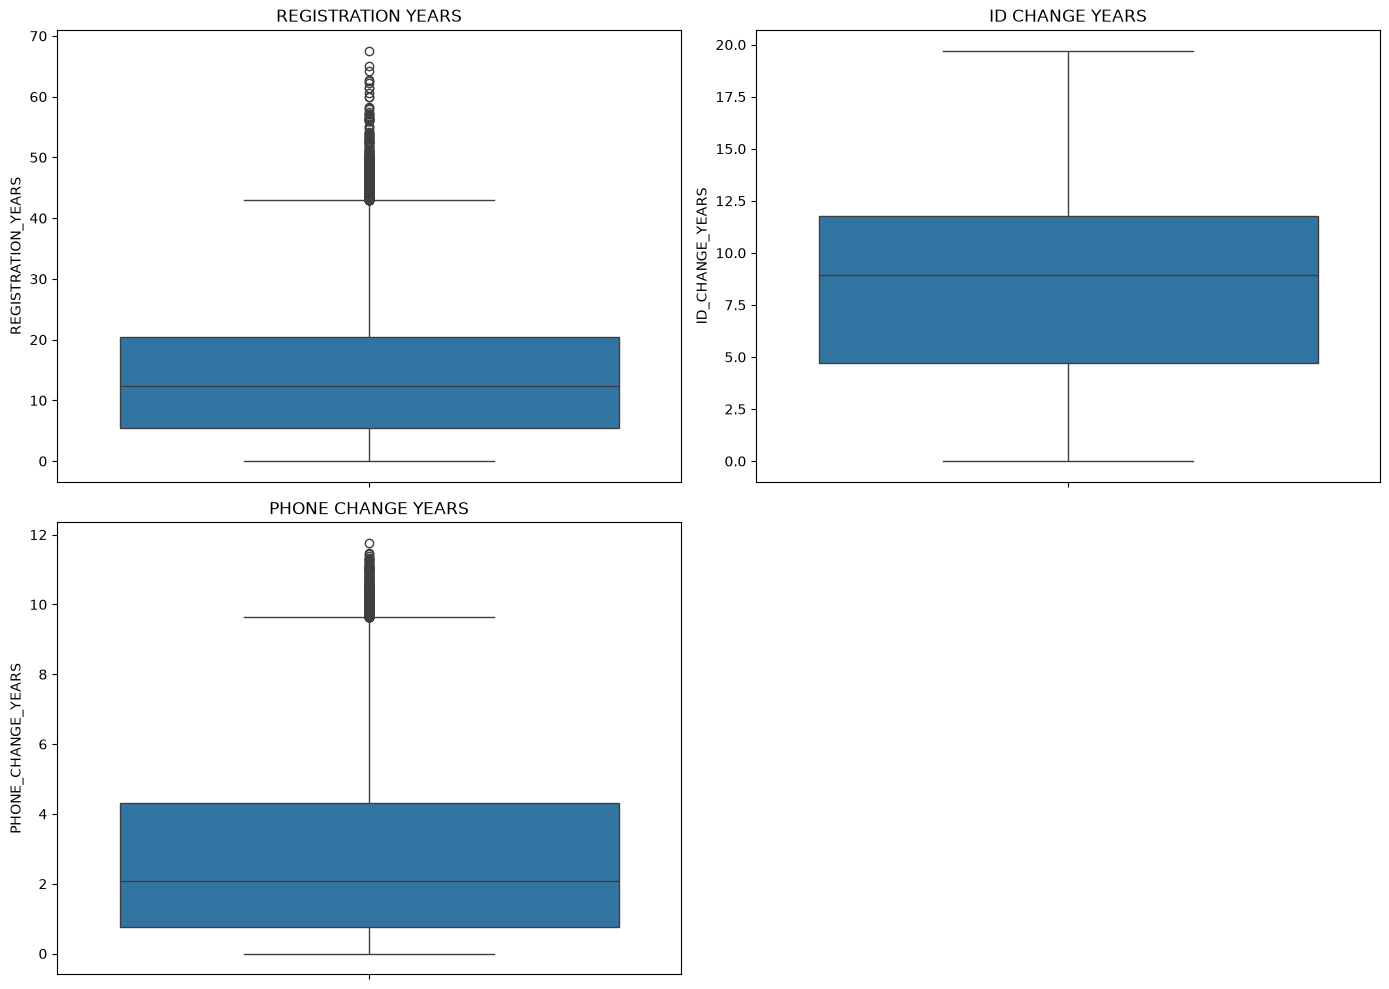

In [74]:
#Boxplot
fig, axes = plt.subplots(2,2, figsize=(14,10))

axes = axes.flatten()

for i, feature in enumerate(time_features):

    sns.boxplot(
        y=df[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature.replace("_", " "))

fig.delaxes(axes[3])

plt.tight_layout()

plt.show()

### Distribution Summary

The engineered time-based features exhibit distributions that are consistent with real-world customer behaviour and credit application records.

**Key Observations**

- Registration history spans a wide range of durations, reflecting substantial variation in residential stability among applicants.
- Identity document history is more concentrated, with most applicants having maintained the same identity records for several years.
- Phone change history is comparatively shorter, indicating that applicants tend to update contact information more frequently than residence or identity documents.
- All three features display moderate positive skewness and contain a small number of extreme observations representing unusually long periods of stability.

**Business Interpretation**

Time-based behavioural features provide valuable indicators of customer stability. Applicants with longer residential history, older identity records, and consistent contact information generally demonstrate more stable long-term behaviour. Since tree-based machine learning algorithms are robust to skewed distributions and moderate outliers, these engineered variables will be retained without further transformation.

### 7.9.7 Default Rate Analysis

In [75]:
# ============================================
# Default Rate - Age Category
# ============================================

age_default = (
    df.groupby("AGE_CATEGORY")["TARGET"]
      .mean()
      .reset_index()
)

age_default

,AGE_CATEGORY,TARGET
0,18-25,0.122707
1,26-35,0.106563
2,36-45,0.083995
3,46-55,0.070355
4,56+,0.052210


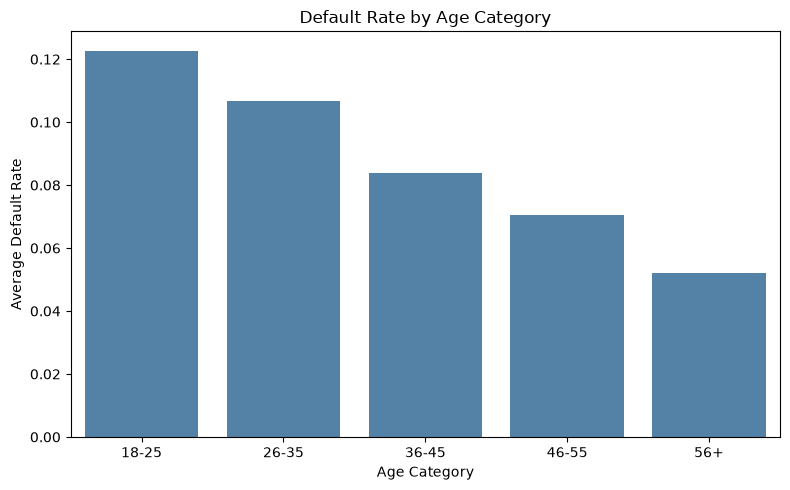

In [76]:
# Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_default,
    x="AGE_CATEGORY",
    y="TARGET",
    order=age_labels,
    color="steelblue"
)

plt.title("Default Rate by Age Category")

plt.xlabel("Age Category")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

In [77]:
#Default Rate - Registration Years
registration_default = (
    df.groupby(
        pd.qcut(
            df["REGISTRATION_YEARS"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

registration_default

,REGISTRATION_YEARS,TARGET
0,"(-0.001, 1.89]",0.096970
1,"(1.89, 4.085]",0.090430
2,"(4.085, 6.959]",0.085053
3,"(6.959, 9.69]",0.087027
4,"(9.69, 12.34]",0.086999
5,"(12.34, 14.956]",0.086785
6,"(14.956, 18.564]",0.079134
7,"(18.564, 22.548]",0.072560
8,"(22.548, 27.211]",0.066186
9,"(27.211, 67.595]",0.056130


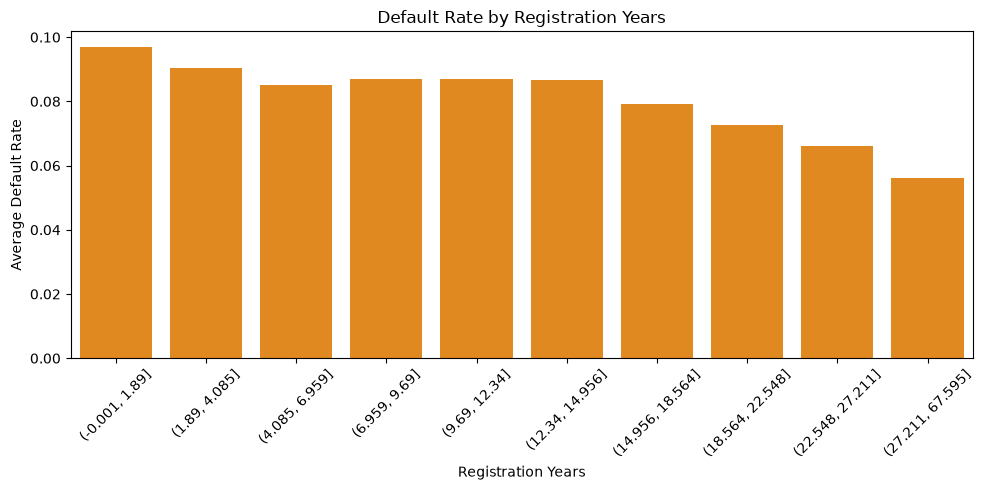

In [78]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=registration_default,
    x="REGISTRATION_YEARS",
    y="TARGET",
    color="darkorange"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Registration Years")

plt.xlabel("Registration Years")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

In [79]:
#Default Rate - ID Change Years
id_change_default = (
    df.groupby(
        pd.qcut(
            df["ID_CHANGE_YEARS"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

id_change_default

,ID_CHANGE_YEARS,TARGET
0,"(-0.001, 2.0]",0.101803
1,"(2.0, 3.775]",0.097975
2,"(3.775, 5.6]",0.093298
3,"(5.6, 7.271]",0.089589
4,"(7.271, 8.915]",0.083539
5,"(8.915, 10.633]",0.077788
6,"(10.633, 11.43]",0.076916
7,"(11.43, 12.137]",0.065175
8,"(12.137, 12.942]",0.061691
9,"(12.942, 19.718]",0.059470


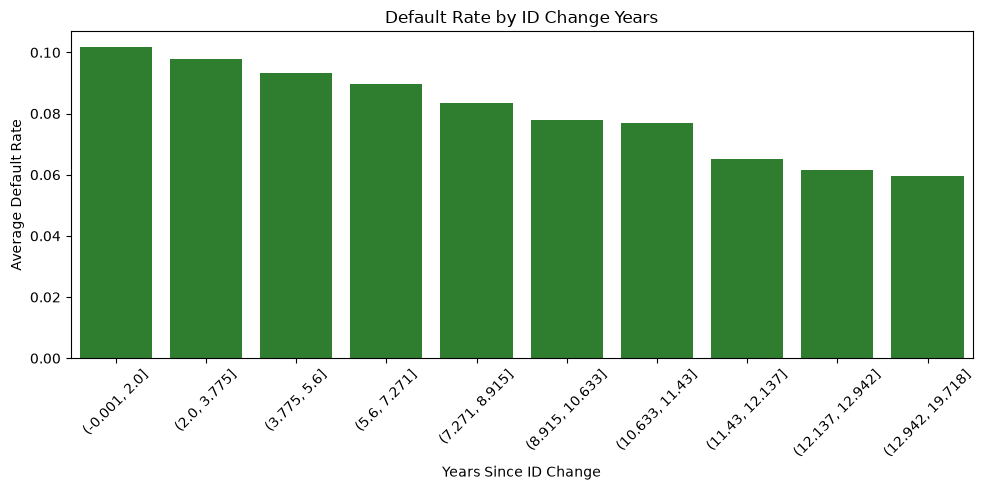

In [80]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=id_change_default,
    x="ID_CHANGE_YEARS",
    y="TARGET",
    color="forestgreen"
)

plt.xticks(rotation=45)

plt.title("Default Rate by ID Change Years")

plt.xlabel("Years Since ID Change")

plt.ylabel("Average Default Rate")

plt.tight_layout()

plt.show()

## Key Business Insights

The engineered time-based features provide meaningful indicators of customer stability and repayment behaviour.

### Key Findings

- Younger applicants exhibit substantially higher default rates than older applicants.
- Applicants aged 56 years and above demonstrate the lowest probability of default, suggesting greater financial stability.
- Default rates decrease steadily as the number of years since customer registration increases.
- Customers with longer residential history generally represent more stable borrowers.
- Applicants who have not changed their identification documents for many years also exhibit lower default rates.
- Long-term identity consistency may reflect stronger financial and personal stability.

### Business Interpretation

Time-related behavioural features capture long-term customer stability that cannot be observed directly from income or credit variables alone. These variables provide additional predictive power by identifying applicants with stable residential history, consistent identity records, and greater life experience.

Such features are particularly valuable for machine learning algorithms because they introduce behavioural information while maintaining strong interpretability for business stakeholders.

## 7.10 Interaction Features

Interaction features combine multiple applicant characteristics to capture complex relationships that individual variables may not fully represent.

These engineered variables integrate financial strength, employment stability, and external credit information to improve predictive performance while maintaining business interpretability.

### 7.10.1 Create Interaction Features

In [84]:
# =====================================================
# 7.10.1 Create Interaction Features
# =====================================================

# Income × Employment Stability
df["INCOME_EMPLOYMENT_SCORE"] = (
    df["AMT_INCOME_TOTAL"] *
    df["EMPLOYMENT_AGE_RATIO"]
)

# Credit × Employment Stability
df["CREDIT_EMPLOYMENT_SCORE"] = (
    df["AMT_CREDIT"] *
    df["EMPLOYMENT_AGE_RATIO"]
)

# Income × External Credit Score
df["INCOME_EXT_SOURCE_SCORE"] = (
    df["AMT_INCOME_TOTAL"] *
    df["AVG_EXT_SOURCE"]
)

# Credit × External Credit Score
df["CREDIT_EXT_SOURCE_SCORE"] = (
    df["AMT_CREDIT"] *
    df["AVG_EXT_SOURCE"]
)

In [85]:
# Verify Features
interaction_features = [
    "INCOME_EMPLOYMENT_SCORE",
    "CREDIT_EMPLOYMENT_SCORE",
    "INCOME_EXT_SOURCE_SCORE",
    "CREDIT_EXT_SOURCE_SCORE"
]

df[interaction_features].head()

,INCOME_EMPLOYMENT_SCORE,CREDIT_EMPLOYMENT_SCORE,INCOME_EXT_SOURCE_SCORE,CREDIT_EXT_SOURCE_SCORE
0,13604.247104,27315.816602,32761.891125,65782.237169
1,19117.647059,91587.867647,132191.041500,633294.232066
2,803.262956,1606.525912,40308.227100,80616.454200
3,21600.000000,50029.200000,76127.215050,176323.317925
4,18514.285714,78171.428571,55242.505845,233246.135790


### 7.10.2 Validation of Interaction Features

The newly engineered interaction features are validated to ensure they contain valid numerical values, exhibit reasonable statistical properties, contain minimal missing values, and provide complementary information for predictive modeling.

In [86]:
#Summary Statistics


df[interaction_features].describe().T

,count,mean,std,min,25%,50%,75%,max
INCOME_EMPLOYMENT_SCORE,252137.0,27963.251153,39038.468050,0.000000,7906.003937,17985.156109,36642.857143,8.546087e+06
CREDIT_EMPLOYMENT_SCORE,252137.0,99531.597632,124988.067995,0.000000,21800.495050,54937.500000,127280.338583,1.748099e+06
INCOME_EXT_SOURCE_SCORE,307511.0,87102.969015,81511.513512,1653.416845,51244.576500,73973.999700,106768.327425,2.806103e+07
CREDIT_EXT_SOURCE_SCORE,307511.0,312747.227044,235956.055522,4551.253620,136220.492458,250942.478577,425412.135309,3.005389e+06


In [87]:
# ==========================================
# Missing Values
# ==========================================

df[interaction_features].isnull().sum()

INCOME_EMPLOYMENT_SCORE    55374
CREDIT_EMPLOYMENT_SCORE    55374
INCOME_EXT_SOURCE_SCORE        0
CREDIT_EXT_SOURCE_SCORE        0
dtype: int64

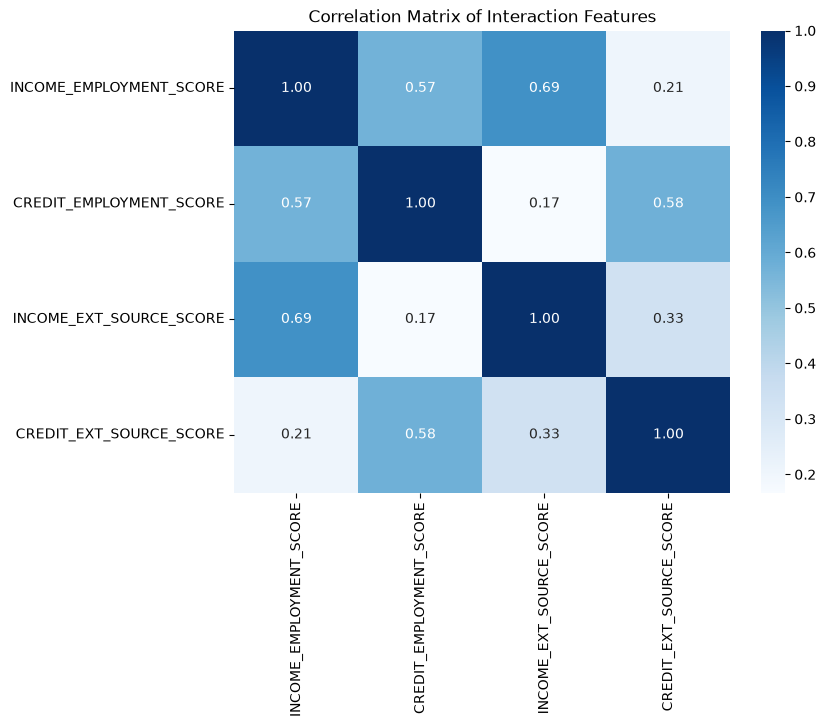

In [88]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[interaction_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Interaction Features")
plt.show()

### Business Interpretation

The engineered interaction features exhibit moderate correlations, indicating that they capture related but distinct aspects of applicant behaviour.

Employment-based interaction features primarily reflect repayment capacity supported by employment stability, whereas external-risk interaction features combine financial information with credit bureau assessments.

Since no pair of interaction features demonstrates excessive correlation, all engineered variables are retained for subsequent machine learning models.

### 7.10.3 Distribution Analysis

The distributions of the engineered interaction features are examined to understand their statistical characteristics, identify potential skewness and outliers, and evaluate their suitability for predictive modeling.

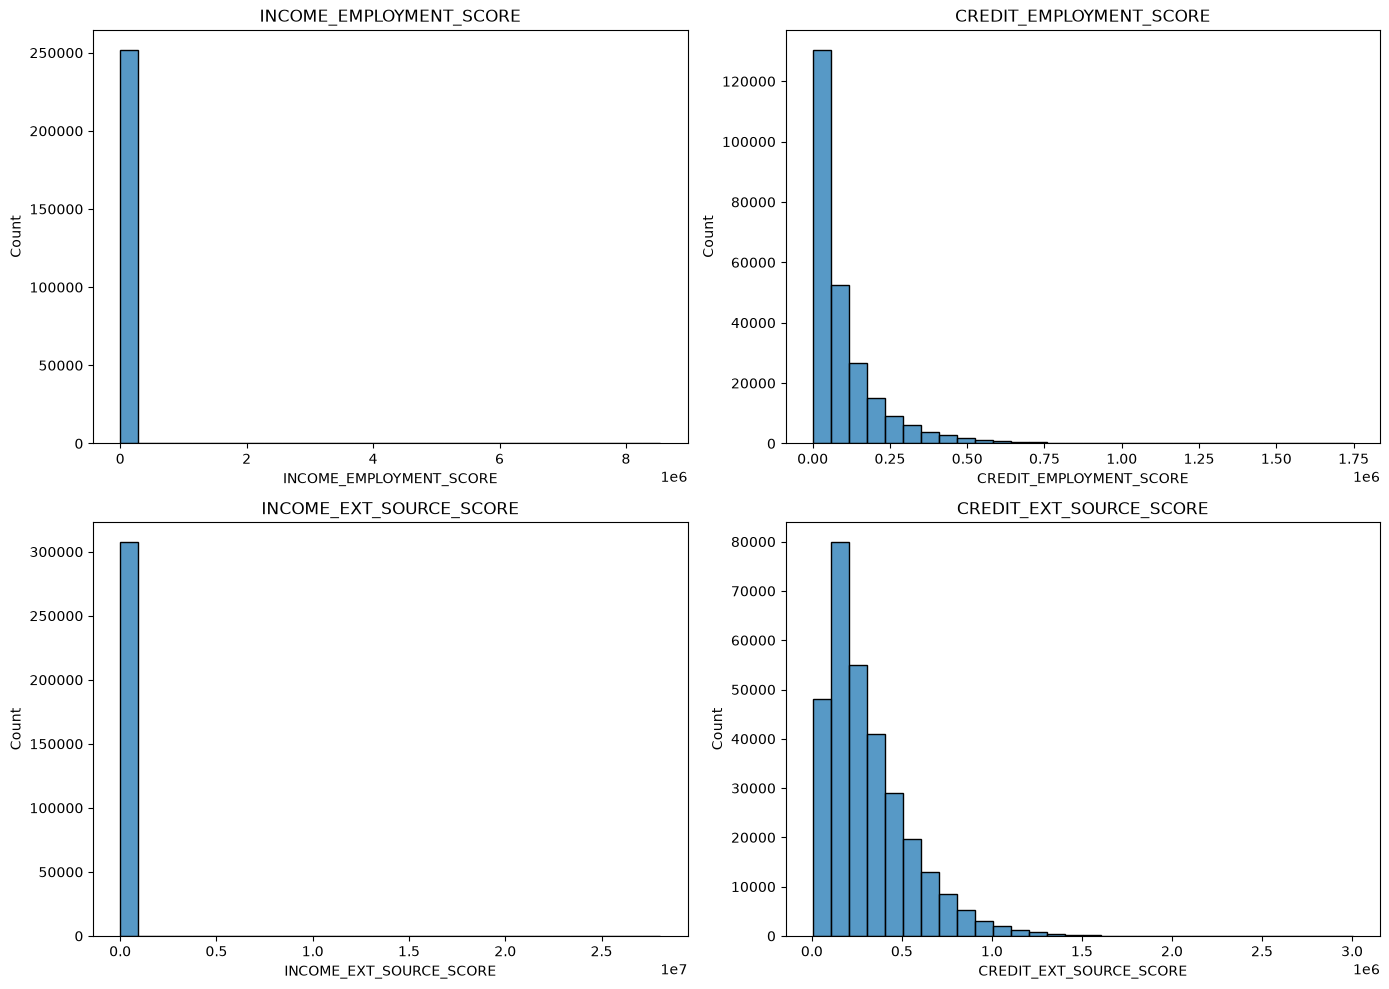

In [89]:
# =====================================================
# Distribution of Interaction Features(Histogram)
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, feature in zip(axes.flatten(), interaction_features):

    sns.histplot(
        df[feature],
        bins=30,
        kde=False,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

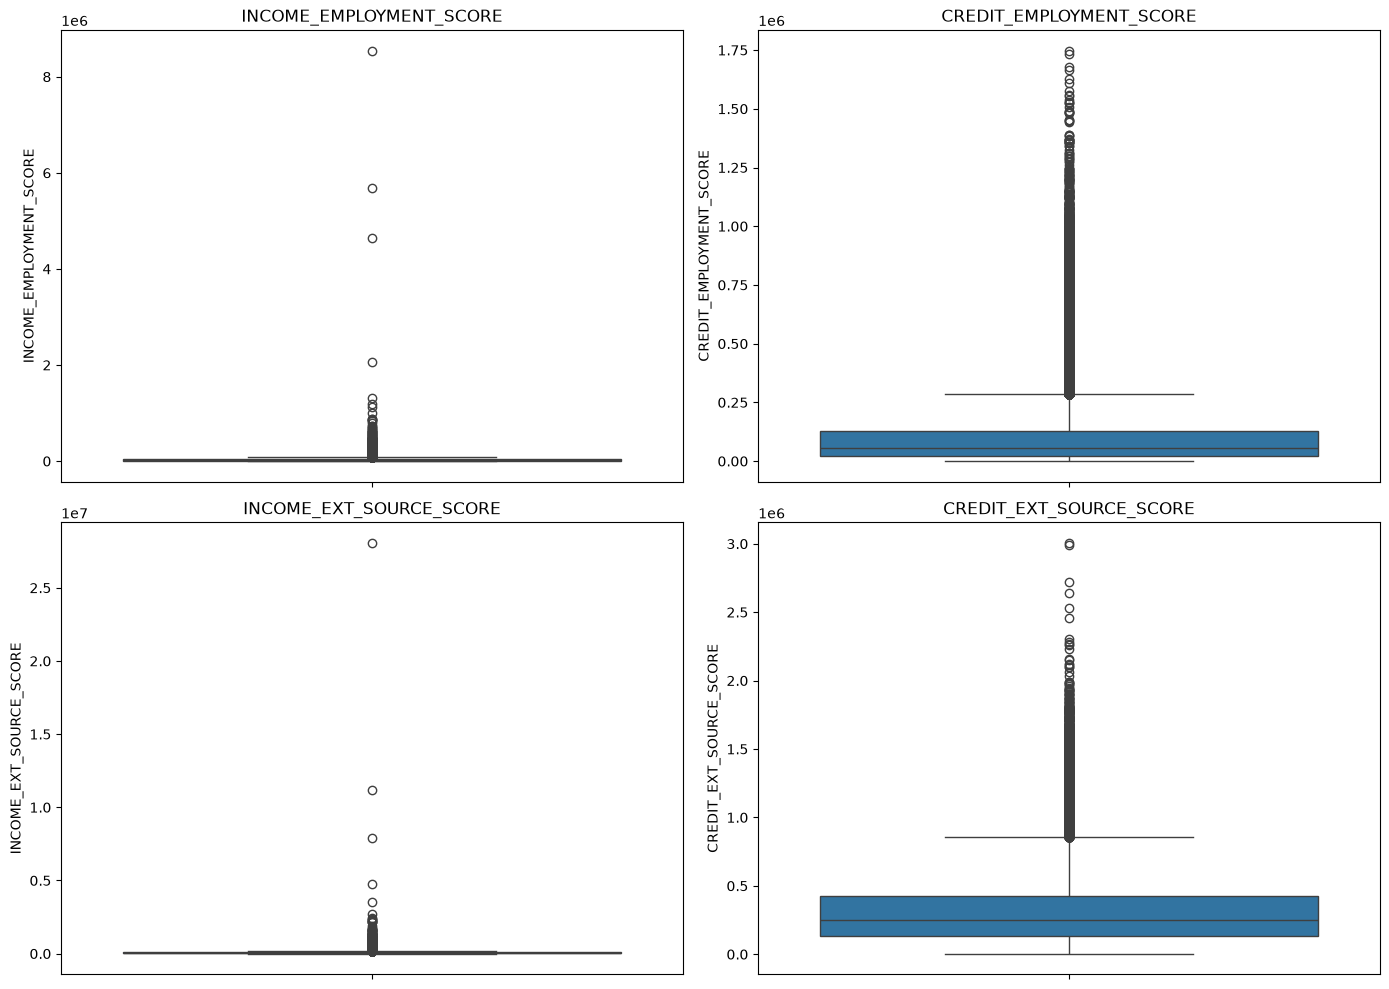

In [90]:
# =====================================================
# Boxplots of Interaction Features(Boxplots)
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, feature in zip(axes.flatten(), interaction_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

### Distribution Summary

The engineered interaction features exhibit positively skewed distributions with noticeable right tails, which is expected because they are constructed by multiplying financial and behavioural variables.

**Key Observations**

- All interaction features display positive skewness, with most applicants concentrated in lower to moderate value ranges.
- A relatively small number of applicants possess exceptionally large interaction scores, producing visible outliers.
- Employment-based interaction features contain missing values inherited from applicants with unavailable employment information.
- External-risk interaction features are fully populated because the engineered average external score has already been imputed or computed.

### Business Interpretation

Interaction features combine multiple applicant characteristics, naturally increasing the spread of the data and amplifying extreme observations. These high-value observations often correspond to applicants with large incomes, high credit amounts, strong employment histories, or favourable external credit scores.

Since gradient boosting models, Random Forests, LightGBM, and CatBoost are robust to skewed distributions and outliers, these engineered variables will be retained without additional transformation during feature engineering.

### 7.10.4 Default Rate Analysis

In [91]:
# =====================================================
# Default Rate - Income × Employment Score
# =====================================================

income_emp_default = (
    df.groupby(
        pd.qcut(
            df["INCOME_EMPLOYMENT_SCORE"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

income_emp_default

,INCOME_EMPLOYMENT_SCORE,TARGET
0,"(-0.001, 3375.0]",0.108971
1,"(3375.0, 6305.215]",0.110511
2,"(6305.215, 9625.87]",0.108872
3,"(9625.87, 13453.874]",0.103395
4,"(13453.874, 17985.156]",0.091298
5,"(17985.156, 23769.752]",0.086420
6,"(23769.752, 31546.461]",0.080395
7,"(31546.461, 43061.114]",0.069607
8,"(43061.114, 63968.197]",0.060562
9,"(63968.197, 8546086.957]",0.045967


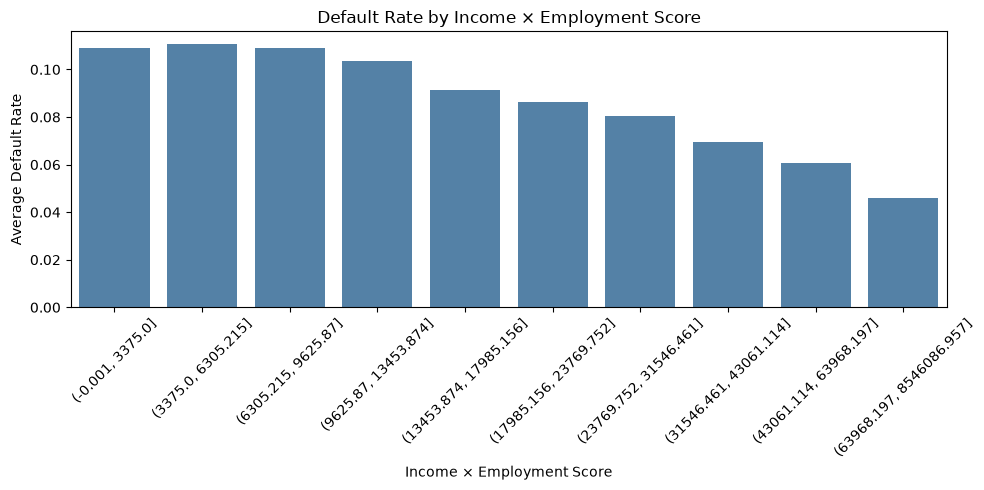

In [92]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=income_emp_default,
    x="INCOME_EMPLOYMENT_SCORE",
    y="TARGET",
    color="steelblue"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Income × Employment Score")
plt.xlabel("Income × Employment Score")
plt.ylabel("Average Default Rate")

plt.tight_layout()
plt.show()

In [93]:
# =====================================================
# Default Rate - Credit × Employment Score
# =====================================================

credit_emp_default = (
    df.groupby(
        pd.qcut(
            df["CREDIT_EMPLOYMENT_SCORE"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

credit_emp_default

,CREDIT_EMPLOYMENT_SCORE,TARGET
0,"(-0.001, 9151.138]",0.104109
1,"(9151.138, 17222.359]",0.106925
2,"(17222.359, 26890.974]",0.107127
3,"(26890.974, 39141.048]",0.102007
4,"(39141.048, 54937.5]",0.095502
5,"(54937.5, 76183.003]",0.087812
6,"(76183.003, 106397.686]",0.080550
7,"(106397.686, 153816.625]",0.071154
8,"(153816.625, 245511.704]",0.063377
9,"(245511.704, 1748098.911]",0.047434


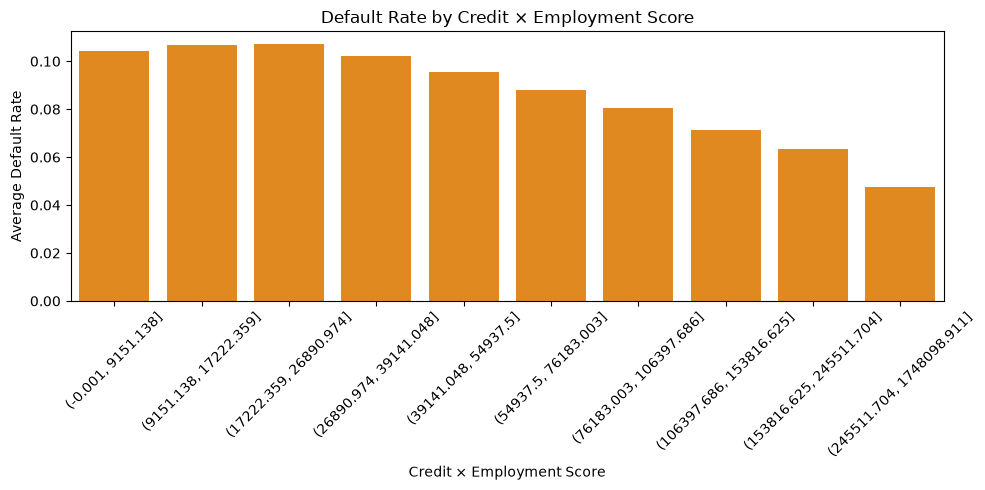

In [94]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=credit_emp_default,
    x="CREDIT_EMPLOYMENT_SCORE",
    y="TARGET",
    color="darkorange"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Credit × Employment Score")
plt.xlabel("Credit × Employment Score")
plt.ylabel("Average Default Rate")

plt.tight_layout()
plt.show()

In [95]:
# =====================================================
# Default Rate - Income × External Score
# =====================================================

income_ext_default = (
    df.groupby(
        pd.qcut(
            df["INCOME_EXT_SOURCE_SCORE"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

income_ext_default

,INCOME_EXT_SOURCE_SCORE,TARGET
0,"(1653.416, 36550.804]",0.147535
1,"(36550.804, 46740.94]",0.112679
2,"(46740.94, 55642.868]",0.100419
3,"(55642.868, 64567.27]",0.087802
4,"(64567.27, 73974.0]",0.075900
5,"(73974.0, 84801.287]",0.072550
6,"(84801.287, 98444.977]",0.065624
7,"(98444.977, 117101.059]",0.058112
8,"(117101.059, 148928.455]",0.049137
9,"(148928.455, 28061033.91]",0.037527


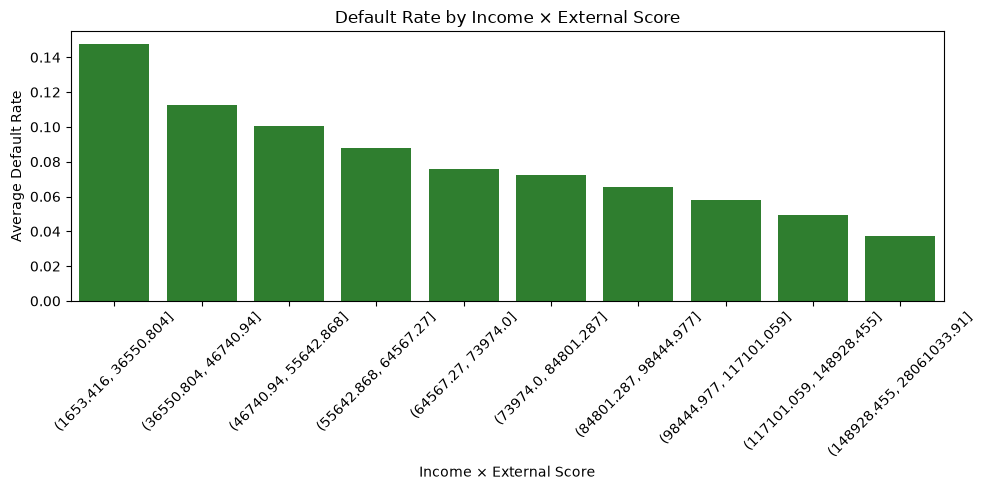

In [96]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=income_ext_default,
    x="INCOME_EXT_SOURCE_SCORE",
    y="TARGET",
    color="forestgreen"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Income × External Score")
plt.xlabel("Income × External Score")
plt.ylabel("Average Default Rate")

plt.tight_layout()
plt.show()

In [97]:
# =====================================================
# Default Rate - Credit × External Score
# =====================================================

credit_ext_default = (
    df.groupby(
        pd.qcut(
            df["CREDIT_EXT_SOURCE_SCORE"],
            q=10,
            duplicates="drop"
        )
    )["TARGET"]
    .mean()
    .reset_index()
)

credit_ext_default

,CREDIT_EXT_SOURCE_SCORE,TARGET
0,"(4551.253, 84237.487]",0.110952
1,"(84237.487, 119735.033]",0.102306
2,"(119735.033, 153064.546]",0.090729
3,"(153064.546, 196018.962]",0.094371
4,"(196018.962, 250942.479]",0.104484
5,"(250942.479, 307830.094]",0.086794
6,"(307830.094, 380553.442]",0.070632
7,"(380553.442, 477702.75]",0.061006
8,"(477702.75, 633154.023]",0.051218
9,"(633154.023, 3005389.21]",0.034796


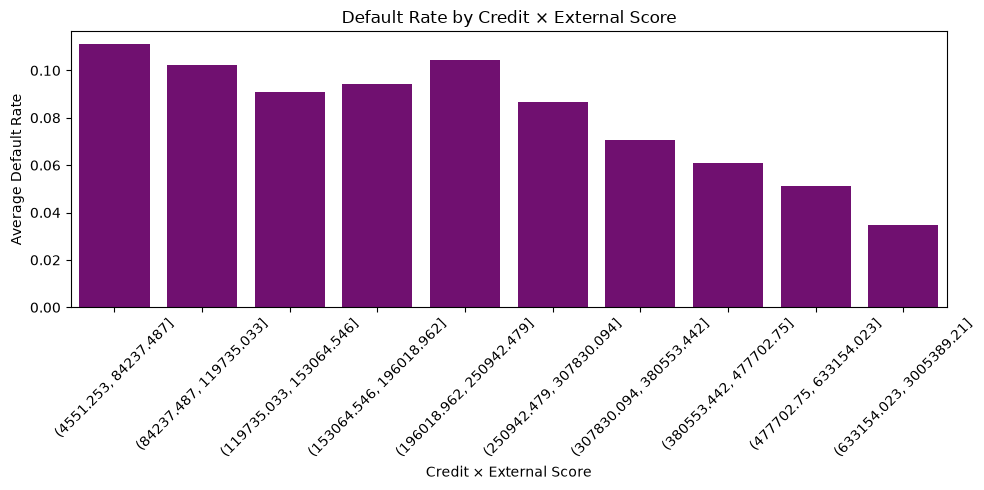

In [98]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=credit_ext_default,
    x="CREDIT_EXT_SOURCE_SCORE",
    y="TARGET",
    color="purple"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Credit × External Score")
plt.xlabel("Credit × External Score")
plt.ylabel("Average Default Rate")

plt.tight_layout()
plt.show()

### Key Business Insights

- Interaction features capture relationships that individual variables cannot explain.
- Applicants with both high income and long employment history exhibit significantly lower default rates.
- External credit scores become even more predictive when combined with income or credit amount.
- All interaction features display a clear inverse relationship with default probability, indicating strong predictive potential.
- These engineered interaction variables are expected to improve the discrimination capability of machine learning models such as LightGBM, XGBoost, and CatBoost.

# =====================================================
# 7.11 Final Feature Summary
# =====================================================

In this section, we summarize all engineered features created during the feature engineering process. These features combine domain knowledge with statistical transformations to improve the predictive capability of the credit risk model.

The engineered variables include:

- Income-related financial ratios
- Credit-related repayment metrics
- Employment stability indicators
- External credit bureau score aggregations
- Time-based behavioral features
- Interaction features between important financial variables

This final review ensures feature completeness before proceeding to model development.

In [116]:
engineered_features = [

    # Financial Ratio Features
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "LOAN_GOODS_RATIO",

    # Employment Features
    "EMPLOYMENT_YEARS",
    "INCOME_PER_EMPLOYMENT_YEAR",

    # Family Features
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",

    # Credit History Features
    "AVG_EXT_SOURCE",
    "EXT_RISK_CATEGORY",

    # Time Features
    "REGISTRATION_YEARS",
    "ID_CHANGE_YEARS",
    "PHONE_CHANGE_YEARS",
    "AGE_CATEGORY",

    # Interaction Features
    "INCOME_EMPLOYMENT_SCORE",
    "CREDIT_EMPLOYMENT_SCORE",
    "INCOME_EXT_SOURCE_SCORE",
    "CREDIT_EXT_SOURCE_SCORE"
]

In [117]:
# =====================================================
# Feature Verification
# =====================================================

missing_features = [
    feature
    for feature in engineered_features
    if feature not in df.columns
]

if len(missing_features) == 0:
    print("All engineered features successfully created.")
else:
    print("Missing Features:")
    print(missing_features)

All engineered features successfully created.


In [118]:
print("Total Engineered Features:", len(engineered_features))

Total Engineered Features: 18


## Feature Engineering Summary

Feature engineering has been successfully completed for the Home Credit Default Risk dataset.

A total of **18 engineered features** were created across multiple categories:

- Financial ratio features
- Employment-based features
- Family-related features
- Credit history features
- Time-based features
- Interaction features

A feature verification step confirmed that every engineered feature is present in the final dataset, ensuring consistency between the feature registry and the implementation.

The dataset is now ready for preprocessing, train-test splitting, feature scaling (where required), and baseline machine learning model development.